In [9]:
pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124


Looking in indexes: https://download.pytorch.org/whl/cu124
Requirement already up-to-date: torch in /home/ubuntu/.local/lib/python3.8/site-packages (2.4.1+cu124)
Requirement already up-to-date: torchvision in /home/ubuntu/.local/lib/python3.8/site-packages (0.19.1+cu124)
Requirement already up-to-date: torchaudio in /home/ubuntu/.local/lib/python3.8/site-packages (2.4.1+cu124)
Note: you may need to restart the kernel to use updated packages.


In [22]:
import torch, torchvision, platform
print(torch.__version__, torchvision.__version__, platform.python_version())


2.5.1+cu121 0.20.1+cu121 3.10.18


In [23]:
import torch
print(torch.__version__, torch.version.cuda, torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))


2.5.1+cu121 12.1 True
NVIDIA RTX A6000


In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # 或 "3"


In [24]:
# Cell 1: Parse CVAT XMLs -> manifest.csv
import os, re, glob, json
import pandas as pd
import xml.etree.ElementTree as ET

# === paths (adjust as needed) ===
PROJECT_ROOT = r"/home/ubuntu/yang/cow_frame/xml/landmark"
LABELS_ROOT = r"/home/ubuntu/yang/cow_frame/xml"   # your uploaded XMLs path
IMAGES_ROOT = r"/home/ubuntu/yang/cow_frame/xml/images"  # TODO: <-- set this to your images folder

os.makedirs(os.path.join(PROJECT_ROOT, "data", "labels"), exist_ok=True)
os.makedirs(os.path.join(PROJECT_ROOT, "data", "images"), exist_ok=True)  # just a placeholder
os.makedirs(os.path.join(PROJECT_ROOT, "train", "logs"), exist_ok=True)
os.makedirs(os.path.join(PROJECT_ROOT, "train", "ckpts"), exist_ok=True)
os.makedirs(os.path.join(PROJECT_ROOT, "infer", "vis"), exist_ok=True)

MANIFEST_CSV = os.path.join(PROJECT_ROOT, "data", "manifest.csv")

# === 13-keypoint order (fixed) ===
LABEL_ORDER = [
    "left_ear_up", "left_ear_edge", "left_ear_down",
    "right_ear_up", "right_ear_edge", "right_ear_down",
    "head",
    "mouth_up", "mouth_down",
    "left_nose", "right_nose",
    "left_eye", "right_eye",
]
label_to_index = {k:i for i,k in enumerate(LABEL_ORDER)}

def xml_to_rows(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    # cow_id from filename e.g., cow12.xml -> "12"
    base = os.path.basename(xml_path)
    m = re.search(r"cow(\d+).*\.xml$", base, re.I)
    # m = re.search(r"cow(\d+)\.xml", base, re.I)
    cow_id = m.group(1) if m else os.path.splitext(base)[0]

    rows = []
    for img_node in root.iter("image"):
        name = img_node.attrib["name"]
        W = int(float(img_node.attrib["width"]))
        H = int(float(img_node.attrib["height"]))
        # collect points by label
        pts = {}  # label -> (x,y)
        for p in img_node.findall("points"):
            lab = p.attrib["label"]
            xy = p.attrib["points"]
            x_str, y_str = xy.split(",")
            x, y = float(x_str), float(y_str)
            pts[lab] = (x, y)

        # ensure all labels exist
        missing = [lab for lab in LABEL_ORDER if lab not in pts]
        if missing:
            raise ValueError(f"Missing labels {missing} in {xml_path}:{name}")

        # compose row
        row = {
            "image_name": name,
            "image_path": os.path.join(IMAGES_ROOT, name),  # full path for dataloader
            "width": W,
            "height": H,
            "cow_id": str(cow_id),
        }
        # add coordinates in fixed order
        for lab in LABEL_ORDER:
            x, y = pts[lab]
            row[f"{lab}_x"] = x
            row[f"{lab}_y"] = y
        rows.append(row)
    return rows

# gather all xmls
xml_files = sorted(glob.glob(os.path.join(LABELS_ROOT, "cow*.xml")))
if not xml_files:
    raise FileNotFoundError("No XMLs found. Make sure your files are under /mnt/data/cow*.xml")

all_rows = []
for xp in xml_files:
    all_rows += xml_to_rows(xp)

df = pd.DataFrame(all_rows)
df.to_csv(MANIFEST_CSV, index=False)
print("Manifest saved to:", MANIFEST_CSV)
print(df.head(3))


Manifest saved to: /home/ubuntu/yang/cow_frame/xml/landmark/data/manifest.csv
   image_name                                         image_path  width  \
0  430912.jpg  /home/ubuntu/yang/cow_frame/xml/images/430912.jpg    537   
1  430913.jpg  /home/ubuntu/yang/cow_frame/xml/images/430913.jpg    456   
2  430914.jpg  /home/ubuntu/yang/cow_frame/xml/images/430914.jpg    444   

   height cow_id  left_ear_up_x  left_ear_up_y  left_ear_edge_x  \
0     735      1         208.89          81.63            24.58   
1     734      1         161.98         114.10            11.40   
2     720      1         160.23         107.06            16.47   

   left_ear_edge_y  left_ear_down_x  ...  mouth_down_x  mouth_down_y  \
0            18.03           159.57  ...        330.45        729.58   
1            13.71           117.81  ...        310.55        722.43   
2            10.56           114.94  ...        294.15        701.82   

   left_nose_x  left_nose_y  right_nose_x  right_nose_y  left_e

In [25]:
#Cell 2
# Cell 2: Letterbox utilities & quick visual sanity check
from PIL import Image, ImageOps, ImageDraw
import numpy as np
import math
import pandas as pd

IMG_SIZE = 256

def letterbox_params(W, H, S=IMG_SIZE):
    scale = min(S / W, S / H)
    new_w = int(round(W * scale))
    new_h = int(round(H * scale))
    pad_left = (S - new_w) // 2
    pad_top = (S - new_h) // 2
    return scale, new_w, new_h, pad_left, pad_top

def letterbox_image(img: Image.Image, S=IMG_SIZE):
    W, H = img.size
    scale, new_w, new_h, pad_left, pad_top = letterbox_params(W, H, S)
    img_resized = img.resize((new_w, new_h), resample=Image.BILINEAR)
    canvas = Image.new("RGB", (S, S), (0,0,0))
    canvas.paste(img_resized, (pad_left, pad_top))
    meta = dict(scale=scale, pad_left=pad_left, pad_top=pad_top, orig_w=W, orig_h=H)
    return canvas, meta

def transform_points_to_letterbox(points_xy, meta):
    # points_xy: np.array shape (N,2) in original coords
    scale = meta["scale"]; pl = meta["pad_left"]; pt = meta["pad_top"]
    pts = points_xy.copy().astype(np.float32)
    pts[:,0] = pts[:,0] * scale + pl
    pts[:,1] = pts[:,1] * scale + pt
    return pts

def transform_points_from_letterbox(points_xy, meta):
    # inverse mapping
    scale = meta["scale"]; pl = meta["pad_left"]; pt = meta["pad_top"]
    pts = points_xy.copy().astype(np.float32)
    pts[:,0] = (pts[:,0] - pl) / scale
    pts[:,1] = (pts[:,1] - pt) / scale
    return pts

def draw_points(image_256: Image.Image, points_xy_256, save_path=None, radius=3):
    img = image_256.copy()
    draw = ImageDraw.Draw(img)
    for (x,y) in points_xy_256:
        draw.ellipse((x-radius, y-radius, x+radius, y+radius), outline=(0,255,0), width=2)
    if save_path:
        img.save(save_path)
    return img

# Quick check on one sample
df = pd.read_csv(MANIFEST_CSV)
sample = df.iloc[0]
img_path = sample["image_path"]
if not os.path.exists(img_path):
    print(f"[Warning] Image not found at {img_path}. Update IMAGES_ROOT in Cell 1.")

try:
    img = Image.open(img_path).convert("RGB")
    pts = []
    for lab in LABEL_ORDER:
        pts.append([sample[f"{lab}_x"], sample[f"{lab}_y"]])
    pts = np.array(pts)

    img256, meta = letterbox_image(img, IMG_SIZE)
    pts256 = transform_points_to_letterbox(pts, meta)
    _ = draw_points(img256, pts256, save_path=os.path.join(PROJECT_ROOT,"infer","vis","sanity_check.png"))
    print("Saved sanity check to infer/vis/sanity_check.png")
except Exception as e:
    print("Sanity check skipped:", e)


Saved sanity check to infer/vis/sanity_check.png


In [8]:
import sys
!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!{sys.executable} -m pip install scikit-learn pillow matplotlib tqdm


Looking in indexes: https://download.pytorch.org/whl/cpu


In [26]:
# Cell 3: Dataset & DataLoader
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import numpy as np
import random

# pairs for L/R swap when horizontal flip on 256x256 canvas
FLIP_SWAP = {
    "left_ear_up": "right_ear_up",
    "left_ear_edge": "right_ear_edge",
    "left_ear_down": "right_ear_down",
    "right_ear_up": "left_ear_up",
    "right_ear_edge": "left_ear_edge",
    "right_ear_down": "left_ear_down",
    "left_eye": "right_eye",
    "right_eye": "left_eye",
    "left_nose": "right_nose",
    "right_nose": "left_nose",
    # mouth_up/down, head don't swap
}

def flip_points_256(pts256: np.ndarray):
    # pts256 in 256x256 coord, flip horizontally
    flipped = pts256.copy()
    flipped[:,0] = IMG_SIZE - 1 - pts256[:,0]
    return flipped

def reorder_labels_for_flip(vec26: np.ndarray):
    # vec26 shape (26,) in LABEL_ORDER; swap L/R labeled coordinates accordingly
    pts = vec26.reshape(-1,2).copy()
    lab2idx = {lab:i for i,lab in enumerate(LABEL_ORDER)}
    swapped = pts.copy()
    for lab, peer in FLIP_SWAP.items():
        i = lab2idx[lab]; j = lab2idx[peer]
        swapped[i], swapped[j] = pts[j].copy(), pts[i].copy()
    return swapped.reshape(-1)

class LandmarkDataset(Dataset):
    def __init__(self, manifest_csv, augment=False):
        self.df = pd.read_csv(manifest_csv)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        pts = []
        for lab in LABEL_ORDER:
            pts.append([row[f"{lab}_x"], row[f"{lab}_y"]])
        pts = np.array(pts, dtype=np.float32)

        img256, meta = letterbox_image(img, IMG_SIZE)
        pts256 = transform_points_to_letterbox(pts, meta)

        vec26 = pts256.reshape(-1)

        # simple augmentation: random horizontal flip on the 256 canvas
        if self.augment and random.random() < 0.5:
            img256 = ImageOps.mirror(img256)
            vec26 = reorder_labels_for_flip(vec26)
            pts256 = vec26.reshape(-1,2)
            pts256 = flip_points_256(pts256)
            vec26 = pts256.reshape(-1)

        # to tensor [0,1], CHW
        x = torch.from_numpy(np.array(img256, dtype=np.float32)/255.0).permute(2,0,1)
        y = torch.from_numpy(vec26)  # (26,)

        sample = {
            "image": x,
            "keypoints": y,
            "cow_id": str(row["cow_id"]),
            "meta": meta,
            "image_path": row["image_path"],
        }
        return sample

# split train/val stratified by cow_id
from sklearn.model_selection import train_test_split

df = pd.read_csv(MANIFEST_CSV)
train_idx, val_idx = train_test_split(
    np.arange(len(df)),
    test_size=0.2,
    random_state=42,
    stratify=df["cow_id"]
)
df.iloc[train_idx].to_csv(os.path.join(PROJECT_ROOT,"data","manifest_train.csv"), index=False)
df.iloc[val_idx].to_csv(os.path.join(PROJECT_ROOT,"data","manifest_val.csv"), index=False)

train_set = LandmarkDataset(os.path.join(PROJECT_ROOT,"data","manifest_train.csv"), augment=True)
val_set   = LandmarkDataset(os.path.join(PROJECT_ROOT,"data","manifest_val.csv"), augment=False)

batch_size = 16  # adjust if needed (e.g., 4 or 16)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=False)
val_loader   = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=0, drop_last=False)

len(train_set), len(val_set)


(102, 26)

In [27]:
# Cell 4: Model definition (ResNet18 -> 26 outputs)
import torch
import torch.nn as nn
import torchvision.models as models

class SimpleLandmarkNet(nn.Module):
    def __init__(self, out_dim=26):
        super().__init__()
        # Avoid downloading weights by default; set weights=None
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)  # 原本是 weights=None
        in_feat = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_feat, out_dim)

    def forward(self, x):
        return self.backbone(x)

model = SimpleLandmarkNet(out_dim=26)
print("Total params (M):", sum(p.numel() for p in model.parameters())/1e6)


Total params (M): 11.18985


In [28]:
# Cell 5: Loss, optimizer, device, training setup
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# DataLoader：打開 pin_memory / 提高 workers（伺服器上可 4~8）
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                          num_workers=4, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_set, batch_size=batch_size, shuffle=False,
                          num_workers=4, pin_memory=True, persistent_workers=True)

# cuDNN 小優化
import torch.backends.cudnn as cudnn
cudnn.benchmark = True

criterion = nn.SmoothL1Loss()  # or nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=5e-5)
num_epochs = 150

# for logging
import csv, time
LOG_CSV = os.path.join(PROJECT_ROOT, "train", "logs", "metrics.csv")
with open(LOG_CSV, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["epoch","train_loss","val_loss","val_mae_px","val_nme","val_pck"])

BEST_CKPT = os.path.join(PROJECT_ROOT, "train", "ckpts", "best.pth")


In [29]:
# Cell 6: Metrics utils (MAE px, NME by inter-ocular distance, PCK@alpha)
import torch
import numpy as np

# indices for eyes
LEFT_EYE_IDX = LABEL_ORDER.index("left_eye")
RIGHT_EYE_IDX = LABEL_ORDER.index("right_eye")

def batched_mae_px(pred26, gt26):
    # pred26, gt26: (B,26) on 256x256 canvas
    pred = pred26.view(-1, 13, 2)
    gt   = gt26.view(-1, 13, 2)
    mae = torch.mean(torch.abs(pred - gt))  # average over all coords
    return mae.item()

def inter_ocular_dist(gt26):
    gt = gt26.view(-1,13,2)
    le = gt[:, LEFT_EYE_IDX, :]   # (B,2)
    re = gt[:, RIGHT_EYE_IDX, :]  # (B,2)
    dist = torch.norm(le - re, dim=1)  # (B,)
    return dist  # per-sample

def batched_nme(pred26, gt26):
    # normalized mean error by inter-ocular distance
    pred = pred26.view(-1,13,2)
    gt   = gt26.view(-1,13,2)
    d = inter_ocular_dist(gt26)  # (B,)
    # mean l2 over points per sample
    per_point_err = torch.norm(pred - gt, dim=2)  # (B,13)
    per_sample_mean = torch.mean(per_point_err, dim=1)  # (B,)
    # avoid div by zero
    d = torch.clamp(d, min=1e-6)
    nme = torch.mean(per_sample_mean / d)
    return nme.item()

def batched_pck(pred26, gt26, alpha=0.05):
    pred = pred26.view(-1,13,2)
    gt   = gt26.view(-1,13,2)
    d = inter_ocular_dist(gt26)  # (B,)
    d = torch.clamp(d, min=1e-6).unsqueeze(1)  # (B,1)
    thresh = alpha * d  # (B,1)
    err = torch.norm(pred - gt, dim=2)  # (B,13)
    hit = (err < thresh).float()
    pck = torch.mean(hit)
    return pck.item()

@torch.no_grad()
def evaluate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, n_samples = 0.0, 0
    preds_all, gts_all = [], []
    for batch in loader:
        x = batch["image"].to(device)
        y = batch["keypoints"].to(device)
        out = model(x)
        loss = criterion(out, y)
        total_loss += loss.item() * x.size(0)
        n_samples += x.size(0)
        preds_all.append(out.detach().cpu())
        gts_all.append(y.detach().cpu())
    if n_samples == 0:
        return 0, 0, 0
    preds_all = torch.cat(preds_all, dim=0)
    gts_all = torch.cat(gts_all, dim=0)
    val_loss = total_loss / n_samples
    val_mae = batched_mae_px(preds_all, gts_all)
    val_nme = batched_nme(preds_all, gts_all)
    val_pck = batched_pck(preds_all, gts_all, alpha=0.05)
    return val_loss, val_mae, val_nme, val_pck


In [30]:
# Cell 7: Training loop
import torch
from tqdm.auto import tqdm
import csv

scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))

freeze_epochs = 10
for p in list(model.backbone.layer1.parameters()) + list(model.backbone.layer2.parameters()):
    p.requires_grad = False

best_nme = float("inf")
for epoch in range(1, num_epochs+1):
    model.train()
    
    running_loss, n_samples = 0.0, 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs}", leave=False)
    for batch in pbar:
        x = batch["image"].to(device)
        y = batch["keypoints"].to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
        n_samples += x.size(0)
        pbar.set_postfix(train_loss=loss.item())
    
    '''
    for batch in train_loader:
        x = batch["image"].to(device, non_blocking=True)
        y = batch["keypoints"].to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
            out = model(x)
            loss = criterion(out, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
    '''
    train_loss = running_loss / max(n_samples,1)
    val_loss, val_mae, val_nme, val_pck = evaluate_epoch(model, val_loader, criterion, device)

    # log
    with open(LOG_CSV, "a", newline="") as f:
        w = csv.writer(f)
        w.writerow([epoch, f"{train_loss:.6f}", f"{val_loss:.6f}", f"{val_mae:.6f}", f"{val_nme:.6f}", f"{val_pck:.6f}"])

    # save best
    if val_nme < best_nme:
        best_nme = val_nme
        torch.save({"model": model.state_dict(), "epoch": epoch}, BEST_CKPT)

    if epoch == freeze_epochs:
        for p in model.backbone.parameters():
            p.requires_grad = True
    
    print(f"[{epoch:03d}] train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_MAE(px)={val_mae:.3f} | val_NME={val_nme:.4f} | val_PCK@0.05={val_pck:.3f}")

print("Best model saved to:", BEST_CKPT, "with NME:", best_nme)


/tmp/ipykernel_45634/4028006515.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))


Epoch 1/150:   0%|          | 0/7 [00:00<?, ?it/s]

[001] train_loss=120.9124 | val_loss=125.7131 | val_MAE(px)=126.213 | val_NME=2.1870 | val_PCK@0.05=0.000


Epoch 2/150:   0%|          | 0/7 [00:00<?, ?it/s]

[002] train_loss=120.0564 | val_loss=124.2144 | val_MAE(px)=124.713 | val_NME=2.1641 | val_PCK@0.05=0.000


...

[148] train_loss=5.8187 | val_loss=5.8135 | val_MAE(px)=6.293 | val_NME=0.1185 | val_PCK@0.05=0.169


Epoch 149/150:   0%|          | 0/7 [00:00<?, ?it/s]

[149] train_loss=5.6311 | val_loss=5.8284 | val_MAE(px)=6.309 | val_NME=0.1171 | val_PCK@0.05=0.136


Epoch 150/150:   0%|          | 0/7 [00:00<?, ?it/s]

[150] train_loss=5.7807 | val_loss=5.6352 | val_MAE(px)=6.112 | val_NME=0.1133 | val_PCK@0.05=0.240
Best model saved to: /home/ubuntu/yang/cow_frame/xml/landmark/train/ckpts/best.pth with NME: 0.11327537894248962


In [ ]:
# Cell 8: Build per-cow prototypes from TRAIN predictions
import torch, json
from collections import defaultdict
import numpy as np

@torch.no_grad()
def predict_dataset_vectors(model, loader, device, normalize=True, rotate_align=True):
    """
    Returns:
      vectors: list of (cow_id, vec26_normed)
    Normalization:
      - subtract centroid
      - divide by inter-ocular distance
      - (optional) rotate to make eye-line horizontal
    """
    model.eval()
    outputs = []
    for batch in loader:
        x = batch["image"].to(device)
        cow_ids = batch["cow_id"]
        out = model(x).detach().cpu().numpy()  # (B,26)
        B = out.shape[0]
        for i in range(B):
            vec = out[i].reshape(13,2)
            if normalize:
                # subtract centroid
                centroid = vec.mean(axis=0, keepdims=True)
                vec = vec - centroid
                # scale by inter-ocular
                le = vec[LEFT_EYE_IDX]; re = vec[RIGHT_EYE_IDX]
                io = np.linalg.norm(re - le)
                if io < 1e-6: io = 1e-6
                vec = vec / io
                if rotate_align:
                    # rotate so that eye line is horizontal
                    dy, dx = (re - le)[1], (re - le)[0]
                    angle = np.arctan2(dy, dx)  # radians
                    ca, sa = np.cos(-angle), np.sin(-angle)
                    R = np.array([[ca, -sa],[sa, ca]], dtype=np.float32)
                    vec = (vec @ R.T)
            outputs.append((cow_ids[i], vec.reshape(-1)))
    return outputs

# load best
ckpt = torch.load(BEST_CKPT, map_location=device)
model.load_state_dict(ckpt["model"])
model.eval()

train_loader_noaug = DataLoader(
    LandmarkDataset(os.path.join(PROJECT_ROOT,"data","manifest_train.csv"), augment=False),
    batch_size=batch_size, shuffle=False, num_workers=0
)

preds = predict_dataset_vectors(model, train_loader_noaug, device)

# build prototypes: mean vector per cow_id
by_cow = defaultdict(list)
for cid, v in preds:
    by_cow[cid].append(v)

prototypes = {cid: np.mean(np.stack(vs, axis=0), axis=0).tolist() for cid, vs in by_cow.items()}

PROTO_JSON = os.path.join(PROJECT_ROOT, "infer", "prototypes.json")
with open(PROTO_JSON, "w") as f:
    json.dump({"prototypes": prototypes, "normalize":"centroid+interocular+(rot-align)"}, f, indent=2)

print("Saved prototypes to:", PROTO_JSON)
print("Cow IDs:", list(prototypes.keys()))


/tmp/ipykernel_107868/3321866786.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(BEST_CKPT, map_location=device)


Saved prototypes to: /home/ubuntu/yang/cow_frame/xml/landmark/infer/prototypes.json
Cow IDs: ['1', '5', '3', '9', '2', '4', '12']


In [39]:
# Cell 8.1: Upper bound with GT landmarks (train->proto using GT; val->classify using GT)
import pandas as pd, numpy as np, json

def normalize_vec_from_pts256(pts256):
    vec = pts256.copy()
    centroid = vec.mean(axis=0, keepdims=True)
    vec = vec - centroid
    le = vec[LEFT_EYE_IDX]; re = vec[RIGHT_EYE_IDX]
    io = np.linalg.norm(re - le) or 1e-6
    vec = vec / io
    dy, dx = (re - le)[1], (re - le)[0]
    angle = np.arctan2(dy, dx); ca, sa = np.cos(-angle), np.sin(-angle)
    R = np.array([[ca,-sa],[sa,ca]], np.float32)
    return (vec @ R.T).reshape(-1)

def pts_to_256_from_row(row):
    pts = np.array([[row[f"{lab}_x"], row[f"{lab}_y"]] for lab in LABEL_ORDER], dtype=np.float32).reshape(13,2)
    scale, _, _, pl, pt = letterbox_params(row["width"], row["height"], IMG_SIZE)
    pts256 = pts.copy()
    pts256[:,0] = pts[:,0]*scale + pl
    pts256[:,1] = pts[:,1]*scale + pt
    return pts256

df_tr = pd.read_csv(os.path.join(PROJECT_ROOT,"data","manifest_train.csv"))
df_va = pd.read_csv(os.path.join(PROJECT_ROOT,"data","manifest_val.csv"))

# build GT prototypes from TRAIN
by_cow = {}
for _, r in df_tr.iterrows():
    v = normalize_vec_from_pts256(pts_to_256_from_row(r))
    by_cow.setdefault(str(r["cow_id"]), []).append(v)
gt_prototypes = {cid: np.mean(np.stack(vs,0),0) for cid, vs in by_cow.items()}

# classify VAL with GT
cow_ids_proto = sorted(gt_prototypes.keys())
proto_matrix = np.stack([gt_prototypes[c] for c in cow_ids_proto], 0)

def cosine_sim(a,b):
    a = a/(np.linalg.norm(a)+1e-9); b = b/(np.linalg.norm(b,axis=1,keepdims=True)+1e-9)
    return (a.reshape(1,-1) @ b.T).flatten()

y_true, y_pred = [], []
for _, r in df_va.iterrows():
    v = normalize_vec_from_pts256(pts_to_256_from_row(r))
    sims = cosine_sim(v, proto_matrix)
    y_true.append(str(r["cow_id"]))
    y_pred.append(cow_ids_proto[int(np.argmax(sims))])

from sklearn.metrics import classification_report, f1_score, confusion_matrix
print("[GT upper bound] report:")
print(classification_report(y_true, y_pred, digits=4))
print("F1 macro:", f1_score(y_true, y_pred, average="macro"))
print("F1 micro:", f1_score(y_true, y_pred, average="micro"))
print("Confusion matrix:\n", confusion_matrix(y_true, y_pred, labels=cow_ids_proto))


[GT upper bound] report:
              precision    recall  f1-score   support

           1     1.0000    1.0000    1.0000         5
          12     1.0000    0.5000    0.6667         2
           2     0.5000    0.5000    0.5000         4
           3     0.5000    0.5000    0.5000         4
           4     0.5714    0.8000    0.6667         5
           5     1.0000    0.5000    0.6667         4
           9     0.3333    0.5000    0.4000         2

    accuracy                         0.6538        26
   macro avg     0.7007    0.6143    0.6286        26
weighted avg     0.7125    0.6538    0.6590        26

F1 macro: 0.6285714285714284
F1 micro: 0.6538461538461539
Confusion matrix:
 [[5 0 0 0 0 0 0]
 [0 1 0 0 1 0 0]
 [0 0 2 2 0 0 0]
 [0 0 0 2 0 0 2]
 [0 0 1 0 4 0 0]
 [0 0 1 0 1 2 0]
 [0 0 0 0 1 0 1]]


In [40]:
# Cell 9: Identity evaluation on VAL set (Top-1, F1, confusion matrix)
import json, numpy as np
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from collections import defaultdict
import torch

# load prototypes
with open(PROTO_JSON, "r") as f:
    protodata = json.load(f)
prototypes = {k: np.array(v, dtype=np.float32) for k,v in protodata["prototypes"].items()}
cow_ids_proto = sorted(prototypes.keys())
proto_matrix = np.stack([prototypes[cid] for cid in cow_ids_proto], axis=0)  # (K,26)

def cosine_sim(a, b):
    # a: (...,26), b:(K,26)
    a_norm = a / (np.linalg.norm(a, axis=-1, keepdims=True)+1e-9)
    b_norm = b / (np.linalg.norm(b, axis=-1, keepdims=True)+1e-9)
    return a_norm @ b_norm.T

# predict normalized vectors for VAL
val_loader_noaug = DataLoader(
    LandmarkDataset(os.path.join(PROJECT_ROOT,"data","manifest_val.csv"), augment=False),
    batch_size=batch_size, shuffle=False, num_workers=0
)
val_vecs = predict_dataset_vectors(model, val_loader_noaug, device)  # list of (cow_id, vec26)

y_true, y_pred = [], []
for cid, vec in val_vecs:
    sims = cosine_sim(vec.reshape(1,-1), proto_matrix).flatten()  # (K,)
    pred_idx = int(np.argmax(sims))
    pred_cid = cow_ids_proto[pred_idx]
    y_true.append(cid)
    y_pred.append(pred_cid)

labels_sorted = sorted(list(set(y_true) | set(y_pred)))
print("Labels:", labels_sorted)
print(classification_report(y_true, y_pred, labels=labels_sorted, digits=4))
print("F1 macro:", f1_score(y_true, y_pred, labels=labels_sorted, average="macro"))
print("F1 micro:", f1_score(y_true, y_pred, labels=labels_sorted, average="micro"))
print("Confusion matrix:\n", confusion_matrix(y_true, y_pred, labels=labels_sorted))


Labels: ['1', '12', '2', '3', '4', '5', '9']
              precision    recall  f1-score   support

           1     1.0000    1.0000    1.0000         5
          12     1.0000    1.0000    1.0000         2
           2     0.3333    0.5000    0.4000         4
           3     0.4000    0.5000    0.4444         4
           4     1.0000    1.0000    1.0000         5
           5     0.0000    0.0000    0.0000         4
           9     0.3333    0.5000    0.4000         2

    accuracy                         0.6538        26
   macro avg     0.5810    0.6429    0.6063        26
weighted avg     0.6000    0.6538    0.6222        26

F1 macro: 0.6063492063492063
F1 micro: 0.6538461538461539
Confusion matrix:
 [[5 0 0 0 0 0 0]
 [0 2 0 0 0 0 0]
 [0 0 2 2 0 0 0]
 [0 0 0 2 0 0 2]
 [0 0 0 0 5 0 0]
 [0 0 4 0 0 0 0]
 [0 0 0 1 0 0 1]]


/home/ubuntu/YuChen/my_conda/envs/nerf/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ubuntu/YuChen/my_conda/envs/nerf/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ubuntu/YuChen/my_conda/envs/nerf/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

In [41]:
# Cell 9.1: k-NN(3) using all TRAIN predicted vectors
train_vecs = predict_dataset_vectors(model, train_loader_noaug, device)  # (cow_id, vec)
X_train = np.stack([v for _,v in train_vecs], 0)
y_train = np.array([cid for cid,_ in train_vecs])

def knn_predict(vec, X, y, k=3):
    sims = cosine_sim(vec.reshape(1,-1), X).flatten()
    idx = np.argsort(-sims)[:k]
    top = y[idx]
    vals, counts = np.unique(top, return_counts=True)
    return vals[np.argmax(counts)]

y_pred_knn = [knn_predict(np.array(v), X_train, y_train, k=3) for _, v in val_vecs]
print("kNN(3) report:")
print(classification_report([cid for cid,_ in val_vecs], y_pred_knn, digits=4))


kNN(3) report:
              precision    recall  f1-score   support

           1     0.8333    1.0000    0.9091         5
          12     0.5000    0.5000    0.5000         2
           2     1.0000    0.7500    0.8571         4
           3     0.7500    0.7500    0.7500         4
           4     0.6250    1.0000    0.7692         5
           5     1.0000    0.7500    0.8571         4
           9     0.0000    0.0000    0.0000         2

    accuracy                         0.7692        26
   macro avg     0.6726    0.6786    0.6632        26
weighted avg     0.7420    0.7692    0.7403        26



/home/ubuntu/YuChen/my_conda/envs/nerf/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ubuntu/YuChen/my_conda/envs/nerf/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ubuntu/YuChen/my_conda/envs/nerf/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

In [15]:
# Cell 10: Single-image inference & visualization & identity
import numpy as np
import torch, json
from PIL import Image, ImageDraw

# reload best & prototypes (in case)
ckpt = torch.load(BEST_CKPT, map_location=device)
model.load_state_dict(ckpt["model"])
model.eval()
with open(PROTO_JSON, "r") as f:
    prototypes = {k: np.array(v, dtype=np.float32) for k,v in json.load(f)["prototypes"].items()}
cow_ids_proto = sorted(prototypes.keys())
proto_matrix = np.stack([prototypes[cid] for cid in cow_ids_proto], axis=0)

def overlay_skeleton(img, pts, save_path):
    im = img.copy()
    dr = ImageDraw.Draw(im)
    # draw points
    for (x,y) in pts:
        dr.ellipse((x-3,y-3,x+3,y+3), outline=(0,255,0), width=2)
    # simple lines: eyes, mouth, nose-mouth, ears-head
    # indices:
    idx = {lab:i for i,lab in enumerate(LABEL_ORDER)}
    def line(a,b,color=(255,0,0)):
        x1,y1 = pts[idx[a]]; x2,y2 = pts[idx[b]]
        dr.line((x1,y1,x2,y2), fill=color, width=2)
    # draw a few connections:
    line("left_eye","right_eye")
    line("mouth_up","mouth_down",(0,255,255))
    line("left_nose","right_nose",(255,255,0))
    line("left_ear_up","head",(255,128,0)); line("right_ear_up","head",(255,128,0))
    im.save(save_path)

def infer_image(image_path):
    img = Image.open(image_path).convert("RGB")
    img256, meta = letterbox_image(img, IMG_SIZE)
    x = torch.from_numpy(np.array(img256, dtype=np.float32)/255.0).permute(2,0,1).unsqueeze(0).to(device)

    with torch.no_grad():
        pred26 = model(x).cpu().numpy().reshape(13,2)

    # visualize on 256x256
    vis_path = os.path.join(PROJECT_ROOT, "infer", "vis", os.path.basename(image_path).rsplit(".",1)[0] + "_pred256.png")
    overlay_skeleton(img256, pred26, vis_path)

    # map back to original image for final overlay
    pts_orig = transform_points_from_letterbox(pred26, meta)
    vis_orig = os.path.join(PROJECT_ROOT, "infer", "vis", os.path.basename(image_path).rsplit(".",1)[0] + "_predORIG.png")
    overlay_skeleton(img, pts_orig, vis_orig)

    # identity similarity
    # normalize vector same as prototype building
    vec = pred26.copy()
    centroid = vec.mean(axis=0, keepdims=True)
    vec = vec - centroid
    le = vec[LEFT_EYE_IDX]; re = vec[RIGHT_EYE_IDX]
    io = np.linalg.norm(re - le)
    if io < 1e-6: io = 1e-6
    vec = vec / io
    # rotate-align
    dy, dx = (re - le)[1], (re - le)[0]
    angle = np.arctan2(dy, dx)
    ca, sa = np.cos(-angle), np.sin(-angle)
    R = np.array([[ca, -sa],[sa, ca]], dtype=np.float32)
    vec = (vec @ R.T).reshape(1,-1)

    sims = cosine_sim(vec, proto_matrix).flatten()
    best_idx = int(np.argmax(sims))
    pred_cow = cow_ids_proto[best_idx]
    scores = {cow_ids_proto[i]: float(sims[i]) for i in range(len(cow_ids_proto))}

    return {
        "predicted_cow_id": pred_cow,
        "similarities": scores,
        "vis_256": vis_path,
        "vis_orig": vis_orig
    }

# Example:
# result = infer_image(df.iloc[0]["image_path"])
# result


/tmp/ipykernel_107868/1498429536.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(BEST_CKPT, map_location=device)


In [16]:
# Cell 11: Plot curves & save summary
import pandas as pd
import matplotlib.pyplot as plt
import json

metrics = pd.read_csv(LOG_CSV)
summary = {
    "best_epoch": int(metrics.iloc[metrics["val_nme"].argmin()]["epoch"]),
    "best_val_nme": float(metrics["val_nme"].min()),
    "best_val_pck": float(metrics.loc[metrics["val_nme"].idxmin(),"val_pck"]),
    "final_epoch": int(metrics.iloc[-1]["epoch"]),
}

SUMMARY_JSON = os.path.join(PROJECT_ROOT, "train", "logs", "summary.json")
with open(SUMMARY_JSON, "w") as f:
    json.dump(summary, f, indent=2)
print("Summary saved to:", SUMMARY_JSON)
print(summary)

# plots
plt.figure()
plt.plot(metrics["epoch"], metrics["train_loss"], label="train_loss")
plt.plot(metrics["epoch"], metrics["val_loss"], label="val_loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("Loss")
plt.savefig(os.path.join(PROJECT_ROOT, "train", "logs", "loss_curve.png"), dpi=150); plt.close()

plt.figure()
plt.plot(metrics["epoch"], metrics["val_nme"], label="val_nme")
plt.plot(metrics["epoch"], metrics["val_mae_px"], label="val_mae_px")
plt.xlabel("epoch"); plt.ylabel("error"); plt.legend(); plt.title("Errors")
plt.savefig(os.path.join(PROJECT_ROOT, "train", "logs", "error_curves.png"), dpi=150); plt.close()

plt.figure()
plt.plot(metrics["epoch"], metrics["val_pck"], label="val_pck")
plt.xlabel("epoch"); plt.ylabel("PCK"); plt.legend(); plt.title("PCK@0.05")
plt.savefig(os.path.join(PROJECT_ROOT, "train", "logs", "pck_curve.png"), dpi=150); plt.close()

print("Saved plots to train/logs/: loss_curve.png, error_curves.png, pck_curve.png")


Summary saved to: /home/ubuntu/yang/cow_frame/xml/landmark/train/logs/summary.json
{'best_epoch': 198, 'best_val_nme': 0.094447, 'best_val_pck': 0.331361, 'final_epoch': 200}
Saved plots to train/logs/: loss_curve.png, error_curves.png, pck_curve.png


In [17]:
# Cell 12: Calibrate open-set threshold T from VAL distribution
import json, numpy as np

# 需要：Cell 8 已建立 prototypes.json；Cell 9 準備好的 val_vecs（或重算一次）
# 若手邊沒有 val_vecs，就重算：
val_loader_noaug = DataLoader(
    LandmarkDataset(os.path.join(PROJECT_ROOT,"data","manifest_val.csv"), augment=False),
    batch_size=batch_size, shuffle=False, num_workers=0
)
val_vecs = predict_dataset_vectors(model, val_loader_noaug, device)  # list of (cow_id, vec)

# 讀 prototype
with open(os.path.join(PROJECT_ROOT,"infer","prototypes.json"), "r") as f:
    pdata = json.load(f)
prototypes = {k: np.array(v, dtype=np.float32) for k,v in pdata["prototypes"].items()}
cow_ids_proto = sorted(prototypes.keys())
proto_matrix = np.stack([prototypes[cid] for cid in cow_ids_proto], axis=0)

def cosine_sim(a, b):
    a = a / (np.linalg.norm(a, axis=-1, keepdims=True) + 1e-9)
    b = b / (np.linalg.norm(b, axis=-1, keepdims=True) + 1e-9)
    return a @ b.T

# 蒐集 genuine 與 impostor 相似度
genuine, impostor = [], []
for cid, vec in val_vecs:
    sims = cosine_sim(np.array(vec, dtype=np.float32).reshape(1,-1), proto_matrix).flatten()
    if cid in cow_ids_proto:
        true_idx = cow_ids_proto.index(cid)
        genuine.append(float(sims[true_idx]))
        others = np.delete(sims, true_idx)
        impostor.append(float(others.max()))
    else:
        # 理論上不會發生（val 都是 7 頭之一）
        impostor.append(float(sims.max()))

genuine = np.array(genuine); impostor = np.array(impostor)
scores_min = float(min(genuine.min(), impostor.min()))
scores_max = float(max(genuine.max(), impostor.max()))
ts = np.linspace(scores_min, scores_max, 1001)

best_T, best_J, best_tpr, best_fpr = 0.0, -1.0, 0.0, 1.0
for t in ts:
    tpr = (genuine >= t).mean()  # 真同一被接受
    fpr = (impostor >= t).mean() # 不同頭被錯誤接受
    J = tpr - fpr
    if J > best_J:
        best_J, best_T, best_tpr, best_fpr = J, float(t), float(tpr), float(fpr)

TH_JSON = os.path.join(PROJECT_ROOT, "infer", "threshold.json")
with open(TH_JSON, "w") as f:
    json.dump({"T": best_T, "J": best_J, "TPR": best_tpr, "FPR": best_fpr,
               "genuine_mean": float(genuine.mean()), "impostor_mean": float(impostor.mean())}, f, indent=2)
print("Saved threshold to:", TH_JSON)
print({"T": best_T, "TPR": best_tpr, "FPR": best_fpr})


Saved threshold to: /home/ubuntu/yang/cow_frame/xml/landmark/infer/threshold.json
{'T': 0.9930290472507477, 'TPR': 0.8461538461538461, 'FPR': 0.7307692307692307}


In [18]:
# Cell 13: Inference with unknown detection + CSV dump
import json, numpy as np, pandas as pd

# 讀模型、prototype、threshold
ckpt = torch.load(BEST_CKPT, map_location=device)
model.load_state_dict(ckpt["model"]); model.eval()
with open(os.path.join(PROJECT_ROOT,"infer","prototypes.json"), "r") as f:
    pdata = json.load(f)
prototypes = {k: np.array(v, dtype=np.float32) for k,v in pdata["prototypes"].items()}
cow_ids_proto = sorted(prototypes.keys())
proto_matrix = np.stack([prototypes[cid] for cid in cow_ids_proto], axis=0)
with open(os.path.join(PROJECT_ROOT,"infer","threshold.json"), "r") as f:
    T = json.load(f)["T"]

def infer_image_open_set(image_path, out_csv=None, save_vis=True):
    img = Image.open(image_path).convert("RGB")
    img256, meta = letterbox_image(img, IMG_SIZE)
    x = torch.from_numpy(np.array(img256, dtype=np.float32)/255.0).permute(2,0,1).unsqueeze(0).to(device)
    with torch.no_grad():
        pred26 = model(x).cpu().numpy().reshape(13,2)

    # 可視化
    base = os.path.basename(image_path).rsplit(".",1)[0]
    if save_vis:
        overlay_skeleton(img256, pred26, os.path.join(PROJECT_ROOT,"infer","vis", f"{base}_pred256.png"))
        overlay_skeleton(img, transform_points_from_letterbox(pred26, meta),
                         os.path.join(PROJECT_ROOT,"infer","vis", f"{base}_predORIG.png"))

    # 產生 normalized 向量以做相似度
    vec = pred26.copy()
    centroid = vec.mean(axis=0, keepdims=True); vec = vec - centroid
    le, re = vec[LEFT_EYE_IDX], vec[RIGHT_EYE_IDX]
    io = np.linalg.norm(re - le) or 1e-6
    vec = vec / io
    dy, dx = (re - le)[1], (re - le)[0]
    angle = np.arctan2(dy, dx); ca, sa = np.cos(-angle), np.sin(-angle)
    R = np.array([[ca,-sa],[sa,ca]], dtype=np.float32)
    vec = (vec @ R.T).reshape(1,-1)

    sims = cosine_sim(vec, proto_matrix).flatten()
    best_idx = int(np.argmax(sims)); max_sim = float(sims[best_idx])
    pred_cow = cow_ids_proto[best_idx]
    is_unknown = bool(max_sim < T)

    # 輸出 CSV（一張圖一列，含 26 維 & 相似度）
    rec = {"image_path": image_path, "pred_cow": pred_cow, "max_sim": max_sim, "is_unknown": is_unknown}
    for i, lab in enumerate(LABEL_ORDER):
        rec[f"{lab}_x_256"] = float(pred26[i,0])
        rec[f"{lab}_y_256"] = float(pred26[i,1])
    if out_csv is None:
        out_csv = os.path.join(PROJECT_ROOT, "infer", "predictions.csv")
    df = pd.DataFrame([rec])
    if os.path.exists(out_csv):
        df.to_csv(out_csv, mode="a", index=False, header=False)
    else:
        df.to_csv(out_csv, index=False)
    return rec

# 用法：
r = infer_image_open_set(r"/home/ubuntu/yang/cow_frame/xml/images/431038.png")
print(r)


/tmp/ipykernel_107868/670997318.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(BEST_CKPT, map_location=device)


{'image_path': '/home/ubuntu/yang/cow_frame/xml/images/431038.png', 'pred_cow': '3', 'max_sim': 0.9997998476028442, 'is_unknown': False, 'left_ear_up_x_256': 77.97452545166016, 'left_ear_up_y_256': 52.33974075317383, 'left_ear_edge_x_256': 7.7293572425842285, 'left_ear_edge_y_256': 63.76947784423828, 'left_ear_down_x_256': 80.27893829345703, 'left_ear_down_y_256': 87.42366790771484, 'right_ear_up_x_256': 183.12928771972656, 'right_ear_up_y_256': 55.888885498046875, 'right_ear_edge_x_256': 249.44020080566406, 'right_ear_edge_y_256': 60.33528518676758, 'right_ear_down_x_256': 186.14788818359375, 'right_ear_down_y_256': 82.24456024169922, 'head_x_256': 137.46533203125, 'head_y_256': 68.23077392578125, 'mouth_up_x_256': 154.08445739746094, 'mouth_up_y_256': 203.96246337890625, 'mouth_down_x_256': 153.50271606445312, 'mouth_down_y_256': 235.7309112548828, 'left_nose_x_256': 140.09523010253906, 'left_nose_y_256': 224.279296875, 'right_nose_x_256': 167.6808624267578, 'right_nose_y_256': 222.7

In [19]:
# Cell 13F: Inference (fused) for single image
import json, numpy as np, pandas as pd
from joblib import load
from PIL import Image
import os

# 載模型與融合件
ckpt = torch.load(BEST_CKPT, map_location=device)
model.load_state_dict(ckpt["model"]); model.eval()

infer_dir = os.path.join(PROJECT_ROOT, "infer")
pca      = load(os.path.join(infer_dir, "fused_pca.joblib"))
sc_geom  = load(os.path.join(infer_dir, "fused_sc_geom.joblib"))
sc_app   = load(os.path.join(infer_dir, "fused_sc_app.joblib"))
logreg   = load(os.path.join(infer_dir, "fused_logreg.joblib"))
with open(os.path.join(infer_dir, "fused_prototypes.json"), "r") as f:
    pdata = json.load(f)
proto_ids = list(map(str, pdata.get("proto_ids", sorted(pdata["prototypes"].keys()))))
P = np.stack([np.array(pdata["prototypes"][cid], dtype=np.float32) for cid in proto_ids], 0)
with open(os.path.join(infer_dir, "fused_threshold.json"), "r") as f:
    TH = json.load(f)["T"]
with open(os.path.join(infer_dir, "fused_config.json"), "r") as f:
    CFG = json.load(f)
LAM = float(CFG["lambda_geom"])

def geom_vec_from_pred26_256(pred26_256: np.ndarray) -> np.ndarray:
    vec = pred26_256.astype(np.float32).copy()
    vec -= vec.mean(axis=0, keepdims=True)
    le, re = vec[LABEL_ORDER.index("left_eye")], vec[LABEL_ORDER.index("right_eye")]
    io = float(np.linalg.norm(re - le)) or 1e-6
    vec /= io
    dy, dx = (re - le)[1], (re - le)[0]
    angle = math.atan2(dy, dx)
    ca, sa = math.cos(-angle), math.sin(-angle)
    R = np.array([[ca,-sa],[sa,ca]], dtype=np.float32)
    return (vec @ R.T).reshape(-1)

def infer_image_fused(image_path, out_csv=None, save_vis=True, save_align=True):
    img = Image.open(image_path).convert("RGB")
    img256, meta = letterbox_image(img, IMG_SIZE)
    x = torch.from_numpy(np.array(img256, dtype=np.float32)/255.0).permute(2,0,1).unsqueeze(0).to(device)

    with torch.no_grad(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
        pred26 = model(x).cpu().numpy().reshape(13,2)

    # 可視化（256 / 原圖）
    base = os.path.basename(image_path).rsplit(".",1)[0]
    vis_dir = os.path.join(infer_dir, "vis"); os.makedirs(vis_dir, exist_ok=True)
    if save_vis:
        overlay_skeleton(img256, pred26, os.path.join(vis_dir, f"{base}_pred256.png"))
        overlay_skeleton(img, transform_points_from_letterbox(pred26, meta),
                         os.path.join(vis_dir, f"{base}_predORIG.png"))

    # 幾何 26D（在 256 畫布）
    g26 = geom_vec_from_pred26_256(pred26)

    # 對齊臉 → 外觀 512D → PCA 32D
    pred_orig = transform_points_from_letterbox(pred26, meta)
    crop = eye_align_crop(img, pred_orig, out_size=256)  # 來自 Cell 15
    if save_align:
        crop.save(os.path.join(vis_dir, f"{base}_aligned.png"))
    xt = app_transform(crop).unsqueeze(0).to(device)
    with torch.no_grad(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
        feat512 = app_backbone(xt).detach().cpu().numpy().reshape(-1)
    app32 = pca.transform(feat512.reshape(1,-1)).reshape(-1)

    # z-score + 融合
    g_z = sc_geom.transform(g26.reshape(1,-1))
    a_z = sc_app.transform(app32.reshape(1,-1))
    fused = np.concatenate([LAM * g_z, a_z], axis=1)  # (1, 26+32)

    # 原型法（for open-set）
    sims = cosine_sim(fused, P).flatten()
    j = int(np.argmax(sims)); max_sim = float(sims[j])
    pred_proto = proto_ids[j]
    is_unknown = bool(max_sim < TH)

    # LogReg（封閉集分類器）
    pred_lr = str(logreg.predict(fused)[0])

    # CSV
    rec = {"image_path": image_path,
           "pred_proto": pred_proto, "max_sim": max_sim, "is_unknown": is_unknown,
           "pred_lr": pred_lr}
    if out_csv is None:
        out_csv = os.path.join(infer_dir, "predictions_fused.csv")
    df = pd.DataFrame([rec])
    if os.path.exists(out_csv):
        df.to_csv(out_csv, mode="a", index=False, header=False)
    else:
        df.to_csv(out_csv, index=False)
    return rec

# 用法：
r = infer_image_fused(r"/home/ubuntu/yang/cow_frame/xml/images/4313_try.png")
print(r)


/tmp/ipykernel_107868/717362979.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(BEST_CKPT, map_location=device)
/home/ubuntu/YuChen/my_conda/envs/nerf/

NameError: name 'eye_align_crop' is not defined

In [20]:
# Cell 14F: Batch (dir or single image) using fused pipeline + export CVAT XML
import glob, time, xml.etree.ElementTree as ET

def floatfmt(x): return f"{x:.2f}"

def build_cvat_xml_fused():
    ann = ET.Element("annotations")
    meta = ET.SubElement(ann, "meta")
    task = ET.SubElement(meta, "task")
    ET.SubElement(task, "id").text = "0"
    ET.SubElement(task, "name").text = "autolabel_fused"
    ET.SubElement(task, "size").text = "0"
    labels = ET.SubElement(task, "labels")
    for lab in LABEL_ORDER:
        l = ET.SubElement(labels, "label")
        ET.SubElement(l, "name").text = lab
        ET.SubElement(l, "color").text = "#000000"
        ET.SubElement(l, "type").text = "any"
        ET.SubElement(l, "attributes")
    ET.SubElement(meta, "dumped").text = time.strftime("%Y-%m-%d %H:%M:%S")
    return ann

def add_image_with_points(root, image_path, pred26_orig):
    W, H = Image.open(image_path).size
    image = ET.SubElement(root, "image", {
        "id": "0", "name": os.path.basename(image_path),
        "width": str(W), "height": str(H)
    })
    for i, lab in enumerate(LABEL_ORDER):
        x, y = pred26_orig[i]
        ET.SubElement(image, "points", {
            "label": lab, "source": "auto", "occluded": "0",
            "points": f"{floatfmt(x)},{floatfmt(y)}",
            "z_order": "0"
        })

def batch_infer_fused(images_path, out_xml=None):
    paths = []
    if os.path.isdir(images_path):
        paths = sorted(glob.glob(os.path.join(images_path, "*.*")))
    else:
        paths = [images_path]
    if out_xml is None:
        out_xml = os.path.join(infer_dir, "autolabel_fused.xml")

    # reset CSV
    out_csv = os.path.join(infer_dir, "predictions_fused.csv")
    if os.path.exists(out_csv):
        os.remove(out_csv)

    root = build_cvat_xml_fused()
    for p in paths:
        try:
            # 先做融合推論（這會寫 CSV / 疊圖 / 對齊臉）
            rec = infer_image_fused(p, out_csv=out_csv, save_vis=True, save_align=True)

            # 同步把 13 點（原圖座標）寫進 XML
            img = Image.open(p).convert("RGB")
            img256, meta = letterbox_image(img, IMG_SIZE)
            x = torch.from_numpy(np.array(img256, dtype=np.float32)/255.0).permute(2,0,1).unsqueeze(0).to(device)
            with torch.no_grad(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
                pred26 = model(x).cpu().numpy().reshape(13,2)
            pred_orig = transform_points_from_letterbox(pred26, meta)
            add_image_with_points(root, p, pred_orig)

            print(os.path.basename(p), "-> proto=", rec["pred_proto"], "sim=", f"{rec['max_sim']:.3f}",
                  "unknown=", rec["is_unknown"], "lr=", rec["pred_lr"])
        except Exception as e:
            print("Skip", p, "due to", e)

    tree = ET.ElementTree(root)
    tree.write(out_xml, encoding="utf-8", xml_declaration=True)
    print("Saved:", out_xml)
    print("Also wrote:", out_csv, "and overlays in infer/vis/ & aligned crops.")
    return out_xml

# 用法：
# batch_infer_fused("/path/to/folder_or_image")


In [21]:
# Cell 14: Batch auto-label to CVAT XML
import os, glob, time
import xml.etree.ElementTree as ET

def floatfmt(x):  # 簡單格式化
    return f"{x:.2f}"

def build_cvat_xml():
    ann = ET.Element("annotations")
    meta = ET.SubElement(ann, "meta")
    task = ET.SubElement(meta, "task")
    ET.SubElement(task, "id").text = "0"
    ET.SubElement(task, "name").text = "autolabel"
    ET.SubElement(task, "size").text = "0"
    labels = ET.SubElement(task, "labels")
    for lab in LABEL_ORDER:
        l = ET.SubElement(labels, "label")
        ET.SubElement(l, "name").text = lab
        ET.SubElement(l, "color").text = "#000000"
        ET.SubElement(l, "type").text = "any"
        ET.SubElement(l, "attributes")
    ET.SubElement(meta, "dumped").text = time.strftime("%Y-%m-%d %H:%M:%S")
    return ann

def add_image_with_points(root, image_path, pred26_orig):
    img = Image.open(image_path)  # 只為了取尺寸
    W, H = img.size
    image = ET.SubElement(root, "image", {
        "id": "0", "name": os.path.basename(image_path),
        "width": str(W), "height": str(H)
    })
    for i, lab in enumerate(LABEL_ORDER):
        x, y = pred26_orig[i]
        ET.SubElement(image, "points", {
            "label": lab, "source": "auto", "occluded": "0",
            "points": f"{floatfmt(x)},{floatfmt(y)}",
            "z_order": "0"
        })

def batch_autolabel_to_cvat_xml(images_dir, out_xml=None):
    if out_xml is None:
        out_xml = os.path.join(PROJECT_ROOT, "infer", "autolabel.xml")
    root = build_cvat_xml()

    img_paths = sorted(glob.glob(os.path.join(images_dir, "*.*")))
    out_csv = os.path.join(PROJECT_ROOT, "infer", "predictions.csv")
    # 清空舊 CSV（若存在）
    if os.path.exists(out_csv):
        os.remove(out_csv)

    for p in img_paths:
        try:
            # 跑推論（同 Cell 13），同時把 256 座標反投影回原圖
            img = Image.open(p).convert("RGB")
            img256, meta = letterbox_image(img, IMG_SIZE)
            x = torch.from_numpy(np.array(img256, dtype=np.float32)/255.0).permute(2,0,1).unsqueeze(0).to(device)
            with torch.no_grad():
                pred26 = model(x).cpu().numpy().reshape(13,2)
            pred_orig = transform_points_from_letterbox(pred26, meta)

            # 存一筆 CSV + 可視化 + unknown 判定
            rec = infer_image_open_set(p, out_csv=out_csv, save_vis=True)

            # 寫入 XML（一張圖一個 <image>，含 13 個 <points>）
            add_image_with_points(root, p, pred_orig)
        except Exception as e:
            print("Skip", p, "due to", e)

    tree = ET.ElementTree(root)
    tree.write(out_xml, encoding="utf-8", xml_declaration=True)
    print("Saved:", out_xml)
    print("Also wrote:", out_csv, "and overlays in infer/vis/")
    return out_xml

# 用法：
batch_autolabel_to_cvat_xml(r"/home/ubuntu/yang/cow_frame/xml/images/431038.png")


Saved: /home/ubuntu/yang/cow_frame/xml/landmark/infer/autolabel.xml
Also wrote: /home/ubuntu/yang/cow_frame/xml/landmark/infer/predictions.csv and overlays in infer/vis/


'/home/ubuntu/yang/cow_frame/xml/landmark/infer/autolabel.xml'

In [22]:
# ---- Cell 14 (修補版)：檔案/資料夾皆可用，且會逐張印出最像哪頭 ----
import os, glob, time, json
import xml.etree.ElementTree as ET
import numpy as np
from PIL import Image

def floatfmt(x): return f"{x:.2f}"

def build_cvat_xml():
    ann = ET.Element("annotations")
    meta = ET.SubElement(ann, "meta")
    task = ET.SubElement(meta, "task")
    ET.SubElement(task, "id").text = "0"
    ET.SubElement(task, "name").text = "autolabel"
    ET.SubElement(task, "size").text = "0"
    labels = ET.SubElement(task, "labels")
    for lab in LABEL_ORDER:
        l = ET.SubElement(labels, "label")
        ET.SubElement(l, "name").text = lab
        ET.SubElement(l, "color").text = "#000000"
        ET.SubElement(l, "type").text = "any"
        ET.SubElement(l, "attributes")
    ET.SubElement(meta, "dumped").text = time.strftime("%Y-%m-%d %H:%M:%S")
    return ann

def add_image_with_points(root, image_path, pred26_orig, image_id, meta_attrs=None):
    img = Image.open(image_path); W, H = img.size
    attrs = {"id": str(image_id), "name": os.path.basename(image_path), "width": str(W), "height": str(H)}
    if meta_attrs:
        attrs.update({
            "pred_cow": str(meta_attrs.get("pred_cow","")),
            "max_sim": floatfmt(meta_attrs.get("max_sim",0.0)),
            "is_unknown": "1" if meta_attrs.get("is_unknown",False) else "0",
        })
    image = ET.SubElement(root, "image", attrs)
    for i, lab in enumerate(LABEL_ORDER):
        x, y = pred26_orig[i]
        ET.SubElement(image, "points", {
            "label": lab, "source": "auto", "occluded": "0",
            "points": f"{floatfmt(x)},{floatfmt(y)}", "z_order": "0"
        })

def batch_autolabel_to_cvat_xml(images_path, out_xml=None):
    if out_xml is None:
        out_xml = os.path.join(PROJECT_ROOT, "infer", "autolabel.xml")
    root = build_cvat_xml()

    # ✅ 同時支援「單檔」或「資料夾」
    if os.path.isfile(images_path):
        img_paths = [images_path]
    else:
        img_paths = sorted(glob.glob(os.path.join(images_path, "*.*")))
    if not img_paths:
        print("No images found under:", images_path)
        return None

    out_csv = os.path.join(PROJECT_ROOT, "infer", "predictions.csv")
    if os.path.exists(out_csv):
        os.remove(out_csv)

    # 讀 threshold & prototypes
    with open(os.path.join(PROJECT_ROOT,"infer","threshold.json"), "r") as f:
        T = json.load(f)["T"]
    with open(os.path.join(PROJECT_ROOT,"infer","prototypes.json"), "r") as f:
        pdata = json.load(f)
    prototypes = {k: np.array(v, dtype=np.float32) for k,v in pdata["prototypes"].items()}
    cow_ids_proto = sorted(prototypes.keys())
    proto_matrix = np.stack([prototypes[cid] for cid in cow_ids_proto], axis=0)

    def cosine_sim(a, b):
        a = a/(np.linalg.norm(a, axis=-1, keepdims=True)+1e-9)
        b = b/(np.linalg.norm(b, axis=-1, keepdims=True)+1e-9)
        return a @ b.T

    image_id = 0
    for p in img_paths:
        try:
            img = Image.open(p).convert("RGB")
            img256, meta = letterbox_image(img, IMG_SIZE)
            x = torch.from_numpy(np.array(img256, dtype=np.float32)/255.0).permute(2,0,1).unsqueeze(0).to(device)
            with torch.no_grad():
                pred26 = model(x).cpu().numpy().reshape(13,2)

            # 可視化
            base = os.path.basename(p).rsplit(".",1)[0]
            overlay_skeleton(img256, pred26, os.path.join(PROJECT_ROOT,"infer","vis", f"{base}_pred256.png"))
            pred_orig = transform_points_from_letterbox(pred26, meta)
            overlay_skeleton(img, pred_orig, os.path.join(PROJECT_ROOT,"infer","vis", f"{base}_predORIG.png"))

            # 相似度 + unknown
            vec = pred26.copy()
            centroid = vec.mean(axis=0, keepdims=True); vec = vec - centroid
            le, re = vec[LEFT_EYE_IDX], vec[RIGHT_EYE_IDX]
            io = np.linalg.norm(re - le) or 1e-6
            vec = vec / io
            dy, dx = (re - le)[1], (re - le)[0]
            angle = np.arctan2(dy, dx); ca, sa = np.cos(-angle), np.sin(-angle)
            R = np.array([[ca,-sa],[sa,ca]], dtype=np.float32)
            vec = (vec @ R.T).reshape(1,-1)

            sims = cosine_sim(vec, proto_matrix).flatten()
            best_idx = int(np.argmax(sims)); max_sim = float(sims[best_idx])
            pred_cow = cow_ids_proto[best_idx]
            is_unknown = bool(max_sim < T)

            # ✅ 終端印出你要看的結論
            print(f"{os.path.basename(p)} -> pred_cow={pred_cow}, max_sim={max_sim:.3f}, unknown={is_unknown}")

            # 追加到 CSV
            import pandas as pd
            rec = {"image_path": p, "pred_cow": pred_cow, "max_sim": max_sim, "is_unknown": is_unknown}
            for i, lab in enumerate(LABEL_ORDER):
                rec[f"{lab}_x_256"] = float(pred26[i,0]); rec[f"{lab}_y_256"] = float(pred26[i,1])
            df = pd.DataFrame([rec])
            if os.path.exists(out_csv):
                df.to_csv(out_csv, mode="a", index=False, header=False)
            else:
                df.to_csv(out_csv, index=False)

            # 寫入 XML（id 自增）
            add_image_with_points(root, p, pred_orig, image_id=image_id,
                                  meta_attrs={"pred_cow": pred_cow, "max_sim": max_sim, "is_unknown": is_unknown})
            image_id += 1

        except Exception as e:
            print("Skip", p, "due to", e)

    tree = ET.ElementTree(root)
    try: ET.indent(tree, space="  ")
    except: pass
    tree.write(out_xml, encoding="utf-8", xml_declaration=True)
    print("Saved:", out_xml)
    print("Also wrote:", out_csv, "and overlays in infer/vis/")
    return out_xml

# 用法（單檔 or 資料夾都行）：
batch_autolabel_to_cvat_xml(r"/home/ubuntu/yang/cow_frame/xml/images/431038.png")
# batch_autolabel_to_cvat_xml(r"C:/images")


431038.png -> pred_cow=3, max_sim=1.000, unknown=False
Saved: /home/ubuntu/yang/cow_frame/xml/landmark/infer/autolabel.xml
Also wrote: /home/ubuntu/yang/cow_frame/xml/landmark/infer/predictions.csv and overlays in infer/vis/


'/home/ubuntu/yang/cow_frame/xml/landmark/infer/autolabel.xml'

In [23]:
# Cell 15: Eye-aligned crop + appearance backbone (frozen)
import math, os, numpy as np
from PIL import Image
import torch, torch.nn as nn
from torchvision.models import resnet18
from torchvision.models import ResNet18_Weights
import torchvision.transforms as T

LEFT_EYE_IDX  = LABEL_ORDER.index("left_eye")
RIGHT_EYE_IDX = LABEL_ORDER.index("right_eye")

# 對齊裁臉：把眼線旋正、控制雙眼距離、裁成 256x256
def eye_align_crop(img: Image.Image, pred_orig_13x2: np.ndarray,
                   out_size=256, eye_frac=0.36, y_offset_frac=0.40):
    """
    eye_frac: 目標雙眼距離佔輸出寬度的比例（0.36 ≈ 92px/256）
    y_offset_frac: crop 盒子的中心相對「雙眼中點」向上偏移比例（0.40 ≈ 含額頭與耳根）
    """
    le = pred_orig_13x2[LEFT_EYE_IDX]   # (x, y)
    re = pred_orig_13x2[RIGHT_EYE_IDX]
    mid = (le + re) / 2.0
    dx, dy = re[0] - le[0], re[1] - le[1]
    eye_dist = max(np.hypot(dx, dy), 1e-6)

    # 旋轉到眼線水平（繞雙眼中點）
    angle_deg = math.degrees(math.atan2(dy, dx))  # 右眼相對左眼角度
    img_rot = img.rotate(-angle_deg, resample=Image.BILINEAR, expand=True, center=(float(mid[0]), float(mid[1])))

    # 旋後的雙眼中點在同一位置（Pillow 旋轉繞 center 不改 center）
    target_eye_dist = out_size * eye_frac
    scale = target_eye_dist / eye_dist
    # 輸出方框在「旋後座標系」中的邊長（以原像素為單位）
    box_size = out_size / scale

    # 從雙眼中點往上移一點（含額頭），再定義正方形方框
    cx, cy = mid[0], mid[1] - y_offset_frac * box_size * 0.5
    left = cx - box_size/2
    top  = cy - box_size/2
    right= cx + box_size/2
    bottom = cy + box_size/2

    crop = img_rot.crop((left, top, right, bottom)).resize((out_size, out_size), Image.BILINEAR)
    return crop

# 外觀 backbone（凍住），輸出 512D
weights = ResNet18_Weights.IMAGENET1K_V1
app_backbone = resnet18(weights=weights)
app_backbone.fc = nn.Identity()
app_backbone.eval().to(device)
for p in app_backbone.parameters():
    p.requires_grad = False

# ✅ 官方預處理（含 Resize/Crop/ToTensor/Normalize）
app_transform = weights.transforms()


In [24]:
# Cell 16: Build {train,val} 幾何向量(26D) + 外觀特徵(512D)
import pandas as pd
from tqdm.auto import tqdm

TRAIN_CSV = os.path.join(PROJECT_ROOT, "data", "manifest_train.csv")
VAL_CSV   = os.path.join(PROJECT_ROOT, "data", "manifest_val.csv")

def geom_vec_from_pred26_256(pred26_256: np.ndarray) -> np.ndarray:
    vec = pred26_256.astype(np.float32).copy()  # (13,2)
    # 去中心
    vec -= vec.mean(axis=0, keepdims=True)
    # 以雙眼距離歸一
    le, re = vec[LEFT_EYE_IDX], vec[RIGHT_EYE_IDX]
    io = float(np.linalg.norm(re - le)) or 1e-6
    vec /= io
    # 旋正
    dy, dx = (re - le)[1], (re - le)[0]
    angle = math.atan2(dy, dx)
    ca, sa = math.cos(-angle), math.sin(-angle)
    R = np.array([[ca, -sa], [sa, ca]], dtype=np.float32)
    vec = (vec @ R.T).reshape(-1)  # 26D
    return vec

@torch.no_grad()
def build_feats(manifest_csv):
    df = pd.read_csv(manifest_csv)
    geom_list, app_list, y_list = [], [], []
    model.eval()

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Extract {os.path.basename(manifest_csv)}"):
        img_path = row["image_path"]
        y_list.append(str(row["cow_id"]))

        # 讀圖 + letterbox + 預測
        img = Image.open(img_path).convert("RGB")
        img256, meta = letterbox_image(img, IMG_SIZE)
        x = torch.from_numpy(np.array(img256, dtype=np.float32)/255.0).permute(2,0,1).unsqueeze(0).to(device)
        with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
            pred = model(x)  # (1,26)
        pred26_256 = pred.detach().cpu().numpy().reshape(13,2)

        # 幾何 26D（在 256 畫布上做規範，與你原決策一致）
        g26 = geom_vec_from_pred26_256(pred26_256)
        geom_list.append(g26)

        # 轉回原圖座標做「對齊裁臉」→ 外觀 512D
        pred26_orig = transform_points_from_letterbox(pred26_256, meta)  # (13,2)
        crop = eye_align_crop(img, pred26_orig, out_size=256)
        xt = app_transform(crop).unsqueeze(0).to(device)
        with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
            feat512 = app_backbone(xt).detach().cpu().numpy().reshape(-1)  # 512D
        app_list.append(feat512)

    return np.stack(geom_list,0), np.stack(app_list,0), np.array(y_list)

geom_tr, app512_tr, y_tr = build_feats(TRAIN_CSV)
geom_va, app512_va, y_va = build_feats(VAL_CSV)

print("Shapes:", geom_tr.shape, app512_tr.shape, len(y_tr), "|", geom_va.shape, app512_va.shape, len(y_va))


Extract manifest_train.csv:   0%|          | 0/102 [00:00<?, ?it/s]

/tmp/ipykernel_107868/3614379030.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
/tmp/ipykernel_107868/3614379030.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):


Extract manifest_val.csv:   0%|          | 0/26 [00:00<?, ?it/s]

/tmp/ipykernel_107868/3614379030.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
/tmp/ipykernel_107868/3614379030.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):


Shapes: (102, 26) (102, 512) 102 | (26, 26) (26, 512) 26


In [25]:
# Cell 17′: 固定最佳配置，訓練並存下 PCA/Scaler/LogReg（融合用）
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from joblib import dump
import numpy as np, os, json

BEST_PCA = 32
LAMBDA_GEOM = 0.5

# 1) 外觀 512D -> PCA 32D（fit on train）
pca = PCA(n_components=BEST_PCA, random_state=42, svd_solver="full")
app32_tr = pca.fit_transform(app512_tr)
app32_va = pca.transform(app512_va)

# 2) 幾何/外觀各自 z-score（fit on train）
sc_geom = StandardScaler().fit(geom_tr)
sc_app  = StandardScaler().fit(app32_tr)
g_tr_z, a_tr_z = sc_geom.transform(geom_tr), sc_app.transform(app32_tr)
g_va_z, a_va_z = sc_geom.transform(geom_va), sc_app.transform(app32_va)

# 3) 融合  =>  26D(geom) * λ  +  32D(app)
Xtr = np.concatenate([LAMBDA_GEOM * g_tr_z, a_tr_z], axis=1)
Xva = np.concatenate([LAMBDA_GEOM * g_va_z, a_va_z], axis=1)

# 4) LogReg（multinomial）
lr = LogisticRegression(max_iter=5000, multi_class="multinomial", C=2.0, n_jobs=-1, random_state=42)
lr.fit(Xtr, y_tr)
yp = lr.predict(Xva)
print("LogReg macro F1 =", f1_score(y_va, yp, average="macro"))
print(classification_report(y_va, yp, digits=4))

# 5) 用「融合向量」建立原型 + 校門檻（open-set）
def cosine_sim(a, b):
    a = a / (np.linalg.norm(a, axis=1, keepdims=True) + 1e-9)
    b = b / (np.linalg.norm(b, axis=1, keepdims=True) + 1e-9)
    return a @ b.T

proto = {}
for cid in np.unique(y_tr):
    proto[cid] = Xtr[y_tr==cid].mean(axis=0)
proto_ids = sorted(proto.keys())
P = np.stack([proto[c] for c in proto_ids], 0)

S = cosine_sim(Xva, P)
genuine, impostor = [], []
for i, cid in enumerate(y_va):
    j = proto_ids.index(cid)
    genuine.append(S[i, j])
    s = S[i].copy(); s[j] = -np.inf
    impostor.append(s.max())
genuine, impostor = np.array(genuine), np.array(impostor)

ts = np.linspace(min(genuine.min(), impostor.min()), max(genuine.max(), impostor.max()), 1001)
best = {"T":0.0, "J":-1, "TPR":0.0, "FPR":1.0}
for t in ts:
    tpr = (genuine >= t).mean()
    fpr = (impostor >= t).mean()
    J = tpr - fpr
    if J > best["J"]:
        best = {"T":float(t), "J":float(J), "TPR":float(tpr), "FPR":float(fpr)}
print("Fused threshold:", best)

# 6) 存檔（推論會讀）
infer_dir = os.path.join(PROJECT_ROOT, "infer")
os.makedirs(infer_dir, exist_ok=True)
dump(pca,      os.path.join(infer_dir, "fused_pca.joblib"))
dump(sc_geom,  os.path.join(infer_dir, "fused_sc_geom.joblib"))
dump(sc_app,   os.path.join(infer_dir, "fused_sc_app.joblib"))
dump(lr,       os.path.join(infer_dir, "fused_logreg.joblib"))
with open(os.path.join(infer_dir, "fused_prototypes.json"), "w") as f:
    json.dump({"prototypes": {str(k): proto[k].tolist() for k in proto_ids},
               "proto_ids": list(map(str, proto_ids))}, f, indent=2)
with open(os.path.join(infer_dir, "fused_threshold.json"), "w") as f:
    json.dump(best, f, indent=2)
with open(os.path.join(infer_dir, "fused_config.json"), "w") as f:
    json.dump({"lambda_geom": LAMBDA_GEOM, "pca_dim": BEST_PCA}, f, indent=2)

print("Saved fused PCA/scalers/LogReg/prototypes/threshold/config to", infer_dir)


/home/ubuntu/YuChen/my_conda/envs/nerf/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogReg macro F1 = 1.0
              precision    recall  f1-score   support

           1     1.0000    1.0000    1.0000         5
          12     1.0000    1.0000    1.0000         2
           2     1.0000    1.0000    1.0000         4
           3     1.0000    1.0000    1.0000         4
           4     1.0000    1.0000    1.0000         5
           5     1.0000    1.0000    1.0000         4
           9     1.0000    1.0000    1.0000         2

    accuracy                         1.0000        26
   macro avg     1.0000    1.0000    1.0000        26
weighted avg     1.0000    1.0000    1.0000        26

Fused threshold: {'T': 0.26551544666290283, 'J': 0.8846153846153847, 'TPR': 0.9230769230769231, 'FPR': 0.038461538461538464}
Saved fused PCA/scalers/LogReg/prototypes/threshold/config to /home/ubuntu/yang/cow_frame/xml/landmark/infer


In [26]:
# Cell 17: PCA(512→128) + 標準化 + concat(26+128) + 多分類器對比
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score, confusion_matrix

n_train, feat_dim = app512_tr.shape  # 例如 (102, 512)
max_k = min(n_train, feat_dim)       # <= 102
k_list = [32, 64, 96, 128]           # 想測的維度
k_list = [k for k in k_list if k <= max_k]  # 過濾掉超標的（會自動剔除 128）

print(f"PCA will try components from {k_list}, because max allowed = {max_k}")

best = None
for k in k_list:
    pca = PCA(n_components=k, random_state=42, svd_solver="full")
    appK_tr = pca.fit_transform(app512_tr)
    appK_va = pca.transform(app512_va)

    # 2) 各自 z-score
    sc_geom = StandardScaler().fit(geom_tr)
    sc_app  = StandardScaler().fit(appK_tr)
    g_tr_z, a_tr_z = sc_geom.transform(geom_tr), sc_app.transform(appK_tr)
    g_va_z, a_va_z = sc_geom.transform(geom_va), sc_app.transform(appK_va)

    # 3) 幾何與外觀 concat，λ ∈ {0.5, 1, 2}
    for lam in (0.5, 1.0, 2.0):
        Xtr = np.concatenate([lam * g_tr_z, a_tr_z], axis=1)
        Xva = np.concatenate([lam * g_va_z, a_va_z], axis=1)

        # 先試三個分類器
        results = []
        for kNN in (3,5):
            clf = KNeighborsClassifier(n_neighbors=kNN, metric="cosine").fit(Xtr, y_tr)
            yp  = clf.predict(Xva)
            f1m = f1_score(y_va, yp, average="macro")
            results.append(("kNN", kNN, f1m))
        lr  = LogisticRegression(max_iter=2000, multi_class="multinomial", C=2.0, n_jobs=-1).fit(Xtr, y_tr)
        f1m = f1_score(y_va, lr.predict(Xva), average="macro")
        results.append(("LogReg", None, f1m))
        svm = LinearSVC(C=1.0).fit(Xtr, y_tr)
        f1m = f1_score(y_va, svm.predict(Xva), average="macro")
        results.append(("LinearSVC", None, f1m))

        # 印摘要
        print(f"\n=== PCA={k}, λ={lam} ===")
        for name, param, f in results:
            if param is None:
                print(f"{name:10s} macro F1={f:.4f}")
            else:
                print(f"{name}(k={param}) macro F1={f:.4f}")

        # 記錄最佳
        for r in results:
            name, param, f = r
            if (best is None) or (f > best["f1"]):
                best = {"pca": k, "lam": lam, "clf": name, "param": param,
                        "f1": f, "sc_geom": sc_geom, "sc_app": sc_app, "pca_obj": pca}

print("\n[Best combo]",
      f"PCA={best['pca']}, λ={best['lam']}, clf={best['clf']}{'('+str(best['param'])+')' if best['param'] else ''},",
      f"macro F1={best['f1']:.4f}")

'''
# 1) 外觀 512D → PCA 128D（fit on train）
pca = PCA(n_components=128, random_state=42)
app128_tr = pca.fit_transform(app512_tr)
app128_va = pca.transform(app512_va)

# 2) 幾何/外觀各自 z-score
sc_geom = StandardScaler().fit(geom_tr)
sc_app  = StandardScaler().fit(app128_tr)
g_tr_z  = sc_geom.transform(geom_tr)
a_tr_z  = sc_app.transform(app128_tr)
g_va_z  = sc_geom.transform(geom_va)
a_va_z  = sc_app.transform(app128_va)

def eval_combo(Xtr, ytr, Xva, yva, tag):
    # kNN(3/5)
    for k in (3,5):
        clf = KNeighborsClassifier(n_neighbors=k, metric="cosine")
        clf.fit(Xtr, ytr)
        yp = clf.predict(Xva)
        f1m = f1_score(yva, yp, average="macro")
        print(f"[{tag}] kNN(k={k})  macro F1={f1m:.4f}")

    # Logistic Regression（multinomial）
    lr = LogisticRegression(max_iter=2000, multi_class="multinomial", C=2.0, n_jobs=-1)
    lr.fit(Xtr, ytr)
    yp = lr.predict(Xva)
    f1m = f1_score(yva, yp, average="macro")
    print(f"[{tag}] LogReg        macro F1={f1m:.4f}")

    # Linear SVM
    svm = LinearSVC(C=1.0)
    svm.fit(Xtr, ytr)
    yp = svm.predict(Xva)
    f1m = f1_score(yva, yp, average="macro")
    print(f"[{tag}] LinearSVC     macro F1={f1m:.4f}")
    # 也可印最好的那個的詳細報告/混淆矩陣
    return

# 3) 幾何與外觀 concat，幾何給權重 λ ∈ {0.5, 1, 2}
for lam in (0.5, 1.0, 2.0):
    Xtr = np.concatenate([lam * g_tr_z, a_tr_z], axis=1)
    Xva = np.concatenate([lam * g_va_z, a_va_z], axis=1)
    print(f"\n=== Geom(λ={lam}) + Appearance(128) → 154D ===")
    eval_combo(Xtr, y_tr, Xva, y_va, tag=f"λ={lam}")

# 4) 如要看最佳組合的完整報告，選一個你剛印出最好的設定再跑：
# clf = KNeighborsClassifier(n_neighbors=3, metric="cosine").fit(Xtr, y_tr)
# yp  = clf.predict(Xva)
# print(classification_report(y_va, yp, digits=4))
# print(confusion_matrix(y_va, yp))
'''

PCA will try components from [32, 64, 96], because max allowed = 102


/home/ubuntu/YuChen/my_conda/envs/nerf/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=== PCA=32, λ=0.5 ===
kNN(k=3) macro F1=0.9394
kNN(k=5) macro F1=0.9394
LogReg     macro F1=1.0000
LinearSVC  macro F1=1.0000


/home/ubuntu/YuChen/my_conda/envs/nerf/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=== PCA=32, λ=1.0 ===
kNN(k=3) macro F1=0.8674
kNN(k=5) macro F1=0.8632
LogReg     macro F1=1.0000
LinearSVC  macro F1=1.0000


...

/home/ubuntu/YuChen/my_conda/envs/nerf/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=== PCA=96, λ=1.0 ===
kNN(k=3) macro F1=0.9127
kNN(k=5) macro F1=0.8904
LogReg     macro F1=1.0000
LinearSVC  macro F1=1.0000


/home/ubuntu/YuChen/my_conda/envs/nerf/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=== PCA=96, λ=2.0 ===
kNN(k=3) macro F1=0.6608
kNN(k=5) macro F1=0.6203
LogReg     macro F1=1.0000
LinearSVC  macro F1=1.0000

[Best combo] PCA=32, λ=0.5, clf=LogReg, macro F1=1.0000


'\n# 1) 外觀 512D → PCA 128D（fit on train）\npca = PCA(n_components=128, random_state=42)\napp128_tr = pca.fit_transform(app512_tr)\napp128_va = pca.transform(app512_va)\n\n# 2) 幾何/外觀各自 z-score\nsc_geom = StandardScaler().fit(geom_tr)\nsc_app  = StandardScaler().fit(app128_tr)\ng_tr_z  = sc_geom.transform(geom_tr)\na_tr_z  = sc_app.transform(app128_tr)\ng_va_z  = sc_geom.transform(geom_va)\na_va_z  = sc_app.transform(app128_va)\n\ndef eval_combo(Xtr, ytr, Xva, yva, tag):\n    # kNN(3/5)\n    for k in (3,5):\n        clf = KNeighborsClassifier(n_neighbors=k, metric="cosine")\n        clf.fit(Xtr, ytr)\n        yp = clf.predict(Xva)\n        f1m = f1_score(yva, yp, average="macro")\n        print(f"[{tag}] kNN(k={k})  macro F1={f1m:.4f}")\n\n    # Logistic Regression（multinomial）\n    lr = LogisticRegression(max_iter=2000, multi_class="multinomial", C=2.0, n_jobs=-1)\n    lr.fit(Xtr, ytr)\n    yp = lr.predict(Xva)\n    f1m = f1_score(yva, yp, average="macro")\n    print(f"[{tag}] LogReg    

In [27]:
# Cell 18: 用融合向量做 prototype + 門檻 T（open-set for fused features）
import json

def cosine_sim(a, b):  # a: [N,d], b: [M,d]
    a = a / (np.linalg.norm(a, axis=1, keepdims=True) + 1e-9)
    b = b / (np.linalg.norm(b, axis=1, keepdims=True) + 1e-9)
    return a @ b.T

# 先選定你在 Cell 17 上面覺得最好的 λ/分類器；這裡以 λ=1 做示範
lam = 1.0
Xtr_fused = np.concatenate([lam * g_tr_z, a_tr_z], axis=1)
Xva_fused = np.concatenate([lam * g_va_z, a_va_z], axis=1)

# 做「每類 prototype」（均值；可改 median/trimmed mean）
proto = {}
for cid in np.unique(y_tr):
    proto[cid] = Xtr_fused[y_tr==cid].mean(axis=0)
proto_ids = sorted(proto.keys())
P = np.stack([proto[c] for c in proto_ids], 0)

# 在 val 上掃門檻（與之前 Cell 12 同精神）
genuine, impostor = [], []
S = cosine_sim(Xva_fused, P)  # [n_val, n_classes]
for i, cid in enumerate(y_va):
    j = proto_ids.index(cid)
    genuine.append(S[i, j])
    s = S[i].copy(); s[j] = -np.inf
    impostor.append(s.max())
genuine = np.array(genuine); impostor = np.array(impostor)
ts = np.linspace(min(genuine.min(), impostor.min()), max(genuine.max(), impostor.max()), 1001)
best_T, best_J, best_tpr, best_fpr = 0.0, -1.0, 0.0, 1.0
for t in ts:
    tpr = (genuine >= t).mean()
    fpr = (impostor >= t).mean()
    J = tpr - fpr
    if J > best_J:
        best_J, best_T, best_tpr, best_fpr = J, float(t), float(tpr), float(fpr)

print({"T": best_T, "TPR": best_tpr, "FPR": best_fpr})

# 存下推論需要的東西（之後 Cell 13/14 可以改用 fused 管線）
from joblib import dump
os.makedirs(os.path.join(PROJECT_ROOT, "infer"), exist_ok=True)
dump(pca, os.path.join(PROJECT_ROOT, "infer", "fused_pca128.joblib"))
dump(sc_geom, os.path.join(PROJECT_ROOT, "infer", "fused_sc_geom.joblib"))
dump(sc_app,  os.path.join(PROJECT_ROOT, "infer", "fused_sc_app.joblib"))
with open(os.path.join(PROJECT_ROOT,"infer","fused_prototypes.json"), "w") as f:
    json.dump({"prototypes": {str(k): proto[k].tolist() for k in proto_ids}}, f, indent=2)
with open(os.path.join(PROJECT_ROOT,"infer","fused_threshold.json"), "w") as f:
    json.dump({"T": best_T, "J": best_J, "TPR": float(best_tpr), "FPR": float(best_fpr)}, f, indent=2)
print("Saved fused PCA/scalers/prototypes/threshold.")


{'T': 0.27691447734832764, 'TPR': 0.7692307692307693, 'FPR': 0.2692307692307692}
Saved fused PCA/scalers/prototypes/threshold.


In [28]:
# Cell 19: Batch export eye-aligned (真正旋正) 256x256 crops
import os, glob, math, numpy as np, pandas as pd
from PIL import Image

# 確保以下物件已存在：model, device, letterbox_image, transform_points_from_letterbox, IMG_SIZE, eye_align_crop
rectified_dir = os.path.join(PROJECT_ROOT, "rectified")
os.makedirs(rectified_dir, exist_ok=True)

def export_aligned_folder(images_path, out_dir=None, out_size=256, eye_frac=0.36, y_offset_frac=0.40):
    """
    images_path: 資料夾 或 單張路徑
    會輸出：<out_dir>/<basename>_aligned.png
    並寫一個 summary CSV (image_path, aligned_path, angle_deg, eye_dist, notes)
    """
    if out_dir is None:
        out_dir = rectified_dir
    os.makedirs(out_dir, exist_ok=True)

    if os.path.isdir(images_path):
        paths = sorted(glob.glob(os.path.join(images_path, "*.*")))
    else:
        paths = [images_path]

    recs = []
    model.eval()
    for p in paths:
        try:
            img = Image.open(p).convert("RGB")
            # 1) 進模型；得到 256 畫布上預測 -> 反投影回原圖座標
            img256, meta = letterbox_image(img, IMG_SIZE)
            x = torch.from_numpy(np.array(img256, dtype=np.float32)/255.0).permute(2,0,1).unsqueeze(0).to(device)
            with torch.no_grad(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
                pred26 = model(x).cpu().numpy().reshape(13,2)
            pred_orig = transform_points_from_letterbox(pred26, meta)  # (13,2)

            # 2) 算雙眼角度與距離（純資訊用）
            le = pred_orig[LABEL_ORDER.index("left_eye")]
            re = pred_orig[LABEL_ORDER.index("right_eye")]
            dx, dy = re[0]-le[0], re[1]-le[1]
            angle_deg = math.degrees(math.atan2(dy, dx))
            eye_dist  = float(np.hypot(dx, dy))

            # 3) 旋正＋尺度對齊＋裁切 ⇒ 256x256
            aligned = eye_align_crop(img, pred_orig, out_size=out_size,
                                     eye_frac=eye_frac, y_offset_frac=y_offset_frac)

            base = os.path.basename(p).rsplit(".",1)[0]
            outp = os.path.join(out_dir, f"{base}_aligned.png")
            aligned.save(outp)

            recs.append({"image_path": p, "aligned_path": outp,
                         "angle_deg": angle_deg, "eye_dist": eye_dist,
                         "eye_frac": eye_frac, "y_offset_frac": y_offset_frac})
            print("OK:", os.path.basename(p), "->", os.path.basename(outp))
        except Exception as e:
            print("Skip:", p, "due to", e)
            recs.append({"image_path": p, "aligned_path": "", "angle_deg": None,
                         "eye_dist": None, "eye_frac": eye_frac,
                         "y_offset_frac": y_offset_frac, "notes": str(e)})

    df = pd.DataFrame(recs)
    df.to_csv(os.path.join(out_dir, "aligned_summary.csv"), index=False)
    print("Saved crops to:", out_dir)
    return out_dir

# 用法（擇一）：
# export_aligned_folder(IMAGES_ROOT)                 # 整個資料夾
export_aligned_folder(r"/home/ubuntu/yang/cow_frame/xml/images/4920_try.png")       # 單張
# 想裁更緊可調 eye_frac=0.42, y_offset_frac=0.30


OK: 4920_try.png -> 4920_try_aligned.png
Saved crops to: /home/ubuntu/yang/cow_frame/xml/landmark/rectified


/tmp/ipykernel_107868/2488955918.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=(device.type=="cuda")):


'/home/ubuntu/yang/cow_frame/xml/landmark/rectified'

In [ ]:
#ensure the file is exit
import os, glob
print("PROJECT_ROOT =", PROJECT_ROOT)
rectified_dir = os.path.join(PROJECT_ROOT, "rectified")
print("rectified_dir exists?", os.path.isdir(rectified_dir))
print("some files:", glob.glob(os.path.join(rectified_dir, "*_aligned.png"))[:5])


PROJECT_ROOT = /home/ubuntu/yang/cow_frame/xml/landmark
rectified_dir exists? True
some files: ['/home/ubuntu/yang/cow_frame/xml/landmark/rectified/431038_aligned.png', '/home/ubuntu/yang/cow_frame/xml/landmark/rectified/431136_aligned.png']


In [29]:
#Cell F0｜不裁切轉正（全圖旋轉＋點位同步變換）
import numpy as np
from PIL import Image
import math

def rotate_fullframe_no_crop(img: Image.Image, angle_deg: float):
    # 以影像中心旋轉，畫布自動放大以完整容納
    return img.rotate(-angle_deg, resample=Image.BILINEAR, expand=True)

def rotate_points(points_xy, angle_deg, orig_size, new_size):
    # points_xy: (N,2) in original image coords
    W, H = orig_size
    Wn, Hn = new_size
    cx, cy = W/2.0, H/2.0
    rad = -angle_deg * math.pi/180.0
    ca, sa = math.cos(rad), math.sin(rad)
    # 平移到中心、旋轉、再平移到新畫布中心
    pts = np.asarray(points_xy, dtype=np.float32)
    x0, y0 = pts[:,0]-cx, pts[:,1]-cy
    xr =  ca*x0 - sa*y0
    yr =  sa*x0 + ca*y0
    nx, ny = xr + (Wn/2.0), yr + (Hn/2.0)
    return np.stack([nx, ny], axis=1)

def eye_roll_angle(le_xy, re_xy):
    dx, dy = re_xy[0]-le_xy[0], re_xy[1]-le_xy[1]
    return math.degrees(math.atan2(dy, dx))  # 0°=水平，>0逆時針

def frontalize_nocrop(img: Image.Image, le_xy, re_xy):
    ang = eye_roll_angle(le_xy, re_xy)   # 讓眼線變水平
    img2 = rotate_fullframe_no_crop(img, ang)
    return img2, ang


In [30]:
#Cell F1｜指標 A+B（roll 與不裁切）

import pandas as pd, os
from PIL import Image

df = pd.read_csv(MANIFEST_CSV)
rows = []
for _, r in df.iterrows():
    p = r["image_path"]
    img = Image.open(p).convert("RGB")
    W,H = img.size
    le = np.array([r["left_eye_x"], r["left_eye_y"]], dtype=np.float32)
    re = np.array([r["right_eye_x"], r["right_eye_y"]], dtype=np.float32)

    roll0 = abs(eye_roll_angle(le, re))
    img2, ang = frontalize_nocrop(img, le, re)
    roll1 = abs(eye_roll_angle(le, re) - ang)  # 旋轉後的理想 roll（近0）

    # 轉正後檢查 13 點是否仍在畫面內、與邊界的最小距離
    pts = np.array([[r[f"{lab}_x"], r[f"{lab}_y"]] for lab in LABEL_ORDER], dtype=np.float32)
    pts2 = rotate_points(pts, ang, (W,H), img2.size)
    in_bounds = np.all((pts2[:,0]>=0)&(pts2[:,0]<img2.size[0])&(pts2[:,1]>=0)&(pts2[:,1]<img2.size[1]))
    margin = np.min(np.stack([
        pts2[:,0],                          # 距左
        img2.size[0]-1 - pts2[:,0],         # 距右
        pts2[:,1],                          # 距上
        img2.size[1]-1 - pts2[:,1]          # 距下
    ],axis=1))

    rows.append({"image_path":p, "roll_before":roll0, "roll_after":roll1, "in_bounds":in_bounds, "min_margin_px":float(margin)})

report = pd.DataFrame(rows)
print("Roll |before| mean±std ->", report["roll_before"].mean(), "±", report["roll_before"].std())
print("Roll |after|  mean±std ->", report["roll_after"].mean(),  "±", report["roll_after"].std())
print("P(|roll|<=3°) before/after ->",
      (report["roll_before"]<=3).mean(), "/", (report["roll_after"]<=3).mean())
print("In-bounds rate ->", report["in_bounds"].mean())
print("Min face-to-border margin (px) median ->", report["min_margin_px"].median())


Roll |before| mean±std -> 2.830727984192675 ± 2.6371557698348407
Roll |after|  mean±std -> 0.0 ± 0.0
P(|roll|<=3°) before/after -> 0.6640625 / 1.0
In-bounds rate -> 1.0
Min face-to-border margin (px) median -> 20.75701904296875


In [33]:
#（選配）Cell F2｜外觀嵌入前後的類內/類間距離

import torch, torchvision.transforms as T
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from collections import defaultdict
from PIL import Image

# 眼對齊臉裁 256×256（僅用於抽特徵；不影響“不裁切”的展示版本）
def eye_aligned_crop(img, le_xy, re_xy, eye_frac=0.30, y_offset_frac=0.40, out=256):
    # 以兩眼中點為中心，讓眼距約佔寬度 eye_frac，往上偏 y_offset_frac
    le, re = np.array(le_xy), np.array(re_xy)
    center = (le+re)/2.0
    eye_dist = np.linalg.norm(re-le)
    target_w = eye_dist / eye_frac
    scale = target_w / img.size[0]
    # 只做旋正和平移到新圖中心，再裁正方形
    ang = eye_roll_angle(le, re)
    img_rot = img.rotate(-ang, resample=Image.BILINEAR, expand=True)
    pts = np.array([le, re])
    pts2 = rotate_points(pts, ang, img.size, img_rot.size)
    le2, re2 = pts2[0], pts2[1]
    center2 = (le2+re2)/2.0
    # 決定裁切框
    w = target_w; h = target_w
    top = center2[1] - y_offset_frac*h
    left = center2[0] - w/2.0
    box = (left, top, left+w, top+h)
    crop = img_rot.crop(box).resize((out,out), Image.BILINEAR)
    return crop

# 抽特徵
weights = ResNet18_Weights.IMAGENET1K_V1
enc = resnet18(weights=weights)
enc.fc = torch.nn.Identity()
enc.eval().cuda() if torch.cuda.is_available() else enc.eval()

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

tr = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

def embed_appearance(pil_im):
    x = tr(pil_im).unsqueeze(0)
    if torch.cuda.is_available(): x = x.cuda()
    with torch.no_grad():
        v = enc(x).cpu().numpy().reshape(-1)  # 512D
    return v

# 取每張圖「未轉正」與「轉正後」的 crop → 512D → PCA32 → z-score
rows_embed = []
for _, r in df.iterrows():
    img = Image.open(r["image_path"]).convert("RGB")
    le = (r["left_eye_x"], r["left_eye_y"]); re = (r["right_eye_x"], r["right_eye_y"])
    crop0 = eye_aligned_crop(img, le, re)                           # 未轉正
    img2, ang = frontalize_nocrop(img, le, re)
    # 由於 eye_aligned_crop 內部自己會旋正到水平，這裡主要比較「以全圖轉正後再裁」的穩定性
    crop1 = eye_aligned_crop(img2, rotate_points(np.array([le,re]), ang, img.size, img2.size)[0],
                                   rotate_points(np.array([le,re]), ang, img.size, img2.size)[1])  # 轉正後

    v0 = embed_appearance(crop0)
    v1 = embed_appearance(crop1)
    rows_embed.append({"cow_id": str(r["cow_id"]), "v0": v0, "v1": v1})

# PCA + z-score
V0 = np.stack([r["v0"] for r in rows_embed], 0)
V1 = np.stack([r["v1"] for r in rows_embed], 0)
pca = PCA(n_components=32, random_state=42).fit(V0)  # 用 before 擬合，客觀比較
A0 = pca.transform(V0); A1 = pca.transform(V1)
A0 = StandardScaler().fit_transform(A0)
A1 = StandardScaler().fit_transform(A1)

def pair_stats(A, labels):
    # 類內/類間平均餘弦距離
    from sklearn.metrics.pairwise import cosine_distances
    D = cosine_distances(A)
    y = np.array(labels)
    mask_intra = (y[:,None]==y[None,:]) & (~np.eye(len(y),dtype=bool))
    mask_inter = (y[:,None]!=y[None,:])
    return D[mask_intra].mean(), D[mask_inter].mean(), D[mask_intra].std()

intra0, inter0, std0 = pair_stats(A0, [r["cow_id"] for r in rows_embed])
intra1, inter1, std1 = pair_stats(A1, [r["cow_id"] for r in rows_embed])
fr0 = (inter0 - intra0)/(std0+1e-6); fr1 = (inter1 - intra1)/(std1+1e-6)

print(f"[Appearance] Intra distance ↓: {intra0:.3f} → {intra1:.3f}")
print(f"[Appearance] Inter distance ↑: {inter0:.3f} → {inter1:.3f}")
print(f"[Appearance] Fisher ratio ↑   : {fr0:.3f} → {fr1:.3f}")


[Appearance] Intra distance ↓: 0.847 → 0.847
[Appearance] Inter distance ↑: 1.034 → 1.034
[Appearance] Fisher ratio ↑   : 0.633 → 0.634


In [34]:
#（選配）Cell F3｜對原型相似度與自動接受率的提升（指標 D）

# === F3′：在 32D 外觀空間內，自行建立「類原型」並比較前/後 ===
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

labels = np.array([r["cow_id"] for r in rows_embed])

def class_prototypes(A, y):
    protos = {}
    for c in np.unique(y):
        protos[c] = A[y==c].mean(axis=0)
    C = sorted(protos.keys())
    P = np.stack([protos[c] for c in C], 0)  # [C, D]
    return C, P

# 前/後 各自的原型
classes0, P0 = class_prototypes(A0, labels)
classes1, P1 = class_prototypes(A1, labels)  # 同一批次，順序應一致

def max_sim_to_own_class(A, y, C, P):
    # 對每張圖：與「自己那一類」的原型做 cosine 相似度
    sim = []
    cls_to_idx = {c:i for i,c in enumerate(C)}
    for a, c in zip(A, y):
        i = cls_to_idx[c]
        s = cosine_similarity(a.reshape(1,-1), P[i].reshape(1,-1))[0,0]
        sim.append(s)
    return np.array(sim)

sim0 = max_sim_to_own_class(A0, labels, classes0, P0)
sim1 = max_sim_to_own_class(A1, labels, classes1, P1)
print(f"Δ self-similarity (mean): {(sim1 - sim0).mean():.4f}")

# 估一個客觀門檻：用「不同類之間」的 impostor 相似度分布，取 95 百分位為 T*
def impostor_sims(A, y, C, P):
    sims = []
    cls_to_idx = {c:i for i,c in enumerate(C)}
    for a, c in zip(A, y):
        for cj in C:
            if cj == c: continue
            j = cls_to_idx[cj]
            sims.append(cosine_similarity(a.reshape(1,-1), P[j].reshape(1,-1))[0,0])
    return np.array(sims)

imp0 = impostor_sims(A0, labels, classes0, P0)
imp1 = impostor_sims(A1, labels, classes1, P1)
T0 = np.quantile(imp0, 0.95)  # 以 95% impostor 為上限，保守地不誤認
T1 = np.quantile(imp1, 0.95)

acc0 = (sim0 >= T0).mean()
acc1 = (sim1 >= T1).mean()
print(f"Auto-accept (own-class@95% impostor) : {acc0:.3f} → {acc1:.3f}")
print(f"T* (95% impostor)                    : {T0:.3f} → {T1:.3f}")



Δ self-similarity (mean): -0.0000
Auto-accept (own-class@95% impostor) : 1.000 → 1.000
T* (95% impostor)                    : 0.005 → 0.005


Figure saved to: /home/ubuntu/yang/cow_frame/xml/landmark/figs/fig4_frontalization_before_after.png


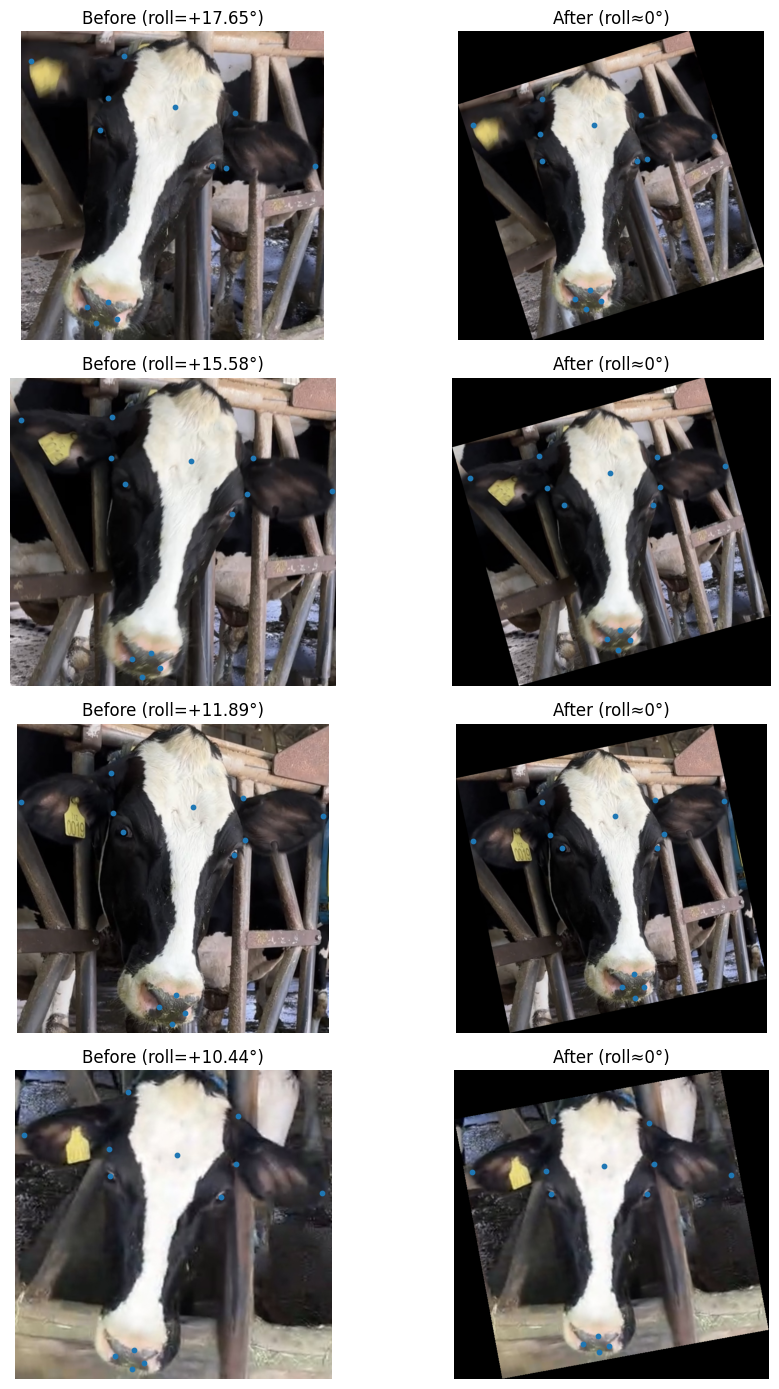

In [12]:
# Figure 4: frontalization before/after (auto-pick the 4 most tilted images)
import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# --- 路徑設定（請改成你的 manifest.csv 與輸出路徑） ---
MANIFEST_CSV = r"/home/ubuntu/yang/cow_frame/xml/landmark/data/manifest.csv"
OUT_DIR      = r"/home/ubuntu/yang/cow_frame/xml/landmark/figs"
OUT_PATH     = os.path.join(OUT_DIR, "fig4_frontalization_before_after.png")
os.makedirs(OUT_DIR, exist_ok=True)

# --- 標籤順序（需與你的標註一致；眼睛會拿來算角度） ---
LABEL_ORDER = [
    "left_ear_up","left_ear_edge","left_ear_down",
    "right_ear_up","right_ear_edge","right_ear_down",
    "head","mouth_up","mouth_down",
    "left_nose","right_nose","left_eye","right_eye",
]

# --- PIL 版本相容：雙線性插值常數 ---
try:
    RESAMPLE = Image.Resampling.BILINEAR
except AttributeError:
    RESAMPLE = Image.BILINEAR

def eye_roll_angle(le_xy, re_xy):
    dx, dy = re_xy[0]-le_xy[0], re_xy[1]-le_xy[1]
    return math.degrees(math.atan2(dy, dx))  # 0°=水平；>0 逆時針

def rotate_fullframe_no_crop(img: Image.Image, angle_deg: float):
    # 「不裁切」轉正：expand=True 讓畫布自動放大完整容納
    return img.rotate(+angle_deg, resample=RESAMPLE, expand=True)

def rotate_points(points_xy, angle_deg, orig_size, new_size):
    """把原圖座標的點，旋轉到新圖座標系。"""
    W, H = orig_size
    Wn, Hn = new_size
    cx, cy = W/2.0, H/2.0
    rad = -angle_deg * math.pi/180.0
    ca, sa = math.cos(rad), math.sin(rad)
    pts = np.asarray(points_xy, dtype=np.float32)
    x0, y0 = pts[:,0]-cx, pts[:,1]-cy
    xr =  ca*x0 - sa*y0
    yr =  sa*x0 + ca*y0
    nx, ny = xr + (Wn/2.0), yr + (Hn/2.0)
    return np.stack([nx, ny], axis=1)

def load_points_from_row(row):
    return np.array([[row[f"{lab}_x"], row[f"{lab}_y"]] for lab in LABEL_ORDER], dtype=np.float32)

# 讀 manifest，計算每張圖的 |roll|
df = pd.read_csv(MANIFEST_CSV)
rows = []
for i, r in df.iterrows():
    le = np.array([r["left_eye_x"], r["left_eye_y"]], dtype=np.float32)
    re = np.array([r["right_eye_x"], r["right_eye_y"]], dtype=np.float32)
    roll = abs(eye_roll_angle(le, re))
    rows.append((roll, i))
rows.sort(reverse=True)  # 由歪到正

# 取最歪的 4 張（可改 k）
k = min(4, len(rows))
sel_idx = [idx for _, idx in rows[:k]]

# 畫 2 欄 × k 列：左「原圖+點」、右「轉正後+點」
fig, axes = plt.subplots(nrows=k, ncols=2, figsize=(10, 3.5*k))
if k == 1:
    axes = np.array([axes])  # 讓 indexing 一致

for row_i, idx in enumerate(sel_idx):
    r = df.iloc[idx]
    img_path = r["image_path"]
    img = Image.open(img_path).convert("RGB")
    W, H = img.size

    # 原圖點
    pts = load_points_from_row(r)
    le = pts[LABEL_ORDER.index("left_eye")]
    re = pts[LABEL_ORDER.index("right_eye")]
    roll_before = eye_roll_angle(le, re)

    # 轉正（不裁切）與點位同步旋轉
    img_rot = rotate_fullframe_no_crop(img, roll_before)
    pts_rot = rotate_points(pts, roll_before, (W, H), img_rot.size)
    le2 = pts_rot[LABEL_ORDER.index("left_eye")]
    re2 = pts_rot[LABEL_ORDER.index("right_eye")]
    roll_after = eye_roll_angle(le2, re2) - roll_before  # 理想上 ~ 0

    # 畫左欄（原圖）
    axL = axes[row_i, 0]
    axL.imshow(img)
    axL.scatter(pts[:,0], pts[:,1], s=10, marker='o')
    axL.set_title(f"Before (roll={roll_before:+.2f}°)")
    axL.axis('off')

    # 畫右欄（轉正後）
    axR = axes[row_i, 1]
    axR.imshow(img_rot)
    axR.scatter(pts_rot[:,0], pts_rot[:,1], s=10, marker='o')
    axR.set_title(f"After (roll≈0°)")
    axR.axis('off')

plt.tight_layout()
plt.savefig(OUT_PATH, dpi=200, bbox_inches="tight")
print(f"Figure saved to: {OUT_PATH}")


In [16]:
# Cell P0: 建立推論套件（bundle）
import os, json, shutil, torch

bundle_dir = os.path.join(PROJECT_ROOT, "release")
os.makedirs(bundle_dir, exist_ok=True)

# 1) 存模型權重（只存 state_dict，推論時會重建同架構）
torch.save({"model": model.state_dict()}, os.path.join(bundle_dir, "model.pth"))

# 2) 存設定與標籤順序
with open(os.path.join(bundle_dir, "config.json"), "w") as f:
    json.dump({"IMG_SIZE": int(IMG_SIZE)}, f)
with open(os.path.join(bundle_dir, "label_order.json"), "w") as f:
    json.dump(LABEL_ORDER, f)

# 3) 複製 open-set 門檻與類原型（若有）
for name in ["prototypes.json", "threshold.json"]:
    src = os.path.join(PROJECT_ROOT, "infer", name)
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(bundle_dir, name))

print("Bundle ready at:", bundle_dir)


Bundle ready at: /home/ubuntu/yang/cow_frame/xml/landmark/release


In [1]:
# Cell USE: 之後重開直接載入與使用
from predictor import Predictor

BUNDLE = r"/home/ubuntu/yang/cow_frame/xml/landmark/release"  # 或 /home/ubuntu/yang/cow_frame/xml/landmark/release
pred = Predictor(BUNDLE, device = "cuda:0")  # 沒 GPU 可省略 device

# 1) 預測單張關鍵點 +（若有原型與門檻）身份判斷
out = pred.predict_keypoints(r"/home/ubuntu/yang/cow_frame/xml/images/431711.png")
idres = pred.predict_identity(out["kpt_256"])
print(idres)  # {'pred_cow': '5', 'max_sim': ..., 'is_unknown': ...}

# 2) 不裁切轉正（for 圖表或報告）
img_rot, pts_rot, angle = pred.frontalize_nocrop(out["img"], out["kpt_orig"])

# 3) 批次自動標註（產 autolabel.xml + 可視化）
pred.autolabel_dir(
    images_dir="/home/ubuntu/yang/cow_frame/xml/images/new_batch",
    out_xml="/home/ubuntu/yang/cow_frame/xml/landmark/infer/autolabel.xml",
    vis_dir="/home/ubuntu/yang/cow_frame/xml/landmark/infer/vis"
)


autolabel_dir patched: now supports out_csv.


/home/ubuntu/yang/cow_frame/xml/predictor.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(os.path.join(bundle_dir, "model.pth"), map_location=self.dev

{'pred_cow': '1', 'max_sim': 0.12142709642648697, 'is_unknown': True}
Saved XML: /home/ubuntu/yang/cow_frame/xml/landmark/infer/autolabel.xml
Saved CSV: /home/ubuntu/yang/cow_frame/xml/landmark/infer/predictions.csv
Saved visualizations to: /home/ubuntu/yang/cow_frame/xml/landmark/infer/vis


('/home/ubuntu/yang/cow_frame/xml/landmark/infer/autolabel.xml',
 '/home/ubuntu/yang/cow_frame/xml/landmark/infer/predictions.csv')

In [1]:
# 重新載入 predictor（或重啟 kernel）
import importlib, predictor
importlib.reload(predictor)
from predictor import Predictor

BUNDLE = "/home/ubuntu/yang/cow_frame/xml/landmark/release"
pred = Predictor(BUNDLE, device = "cuda:0")  # 先不強制 cuda，讓它自動偵測

out = pred.predict_keypoints(r"/home/ubuntu/yang/cow_frame/xml/images/431711.png")
idres = pred.predict_identity(out["kpt_256"])
print(idres) 

xml_path = "/home/ubuntu/yang/cow_frame/xml/landmark/infer/autolabel.xml"
vis_dir  = "/home/ubuntu/yang/cow_frame/xml/landmark/infer/vis"
csv_path = "/home/ubuntu/yang/cow_frame/xml/landmark/infer/predictions.csv"

pred.autolabel_dir(
    images_dir="/home/ubuntu/yang/cow_frame/xml/images/new_batch",
    out_xml=xml_path,
    vis_dir=vis_dir,
    out_csv=csv_path,
    overwrite_csv=True  # 如要累加改成 False
)


autolabel_dir patched: now supports out_csv.
autolabel_dir patched: now supports out_csv.


/home/ubuntu/yang/cow_frame/xml/predictor.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(os.path.join(bundle_dir, "model.pth"), map_location=self.dev

{'pred_cow': '1', 'max_sim': 0.12142709642648697, 'is_unknown': True}
Saved XML: /home/ubuntu/yang/cow_frame/xml/landmark/infer/autolabel.xml
Saved CSV: /home/ubuntu/yang/cow_frame/xml/landmark/infer/predictions.csv
Saved visualizations to: /home/ubuntu/yang/cow_frame/xml/landmark/infer/vis


('/home/ubuntu/yang/cow_frame/xml/landmark/infer/autolabel.xml',
 '/home/ubuntu/yang/cow_frame/xml/landmark/infer/predictions.csv')

In [12]:
import os, glob
print("XML exists:", os.path.exists(xml_path))
print("CSV exists:", os.path.exists(csv_path))
print("VIS count:", len(glob.glob(os.path.join(vis_dir, "*.png"))))


XML exists: True
CSV exists: True
VIS count: 7


In [3]:
import torch, os, platform, sys, subprocess

print("platform:", platform.platform())
print("python:", sys.version)
print("torch:", torch.__version__, "| cuda available:", torch.cuda.is_available(), "| torch.cuda:", torch.version.cuda)
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
try:
    print(subprocess.check_output(["nvidia-smi"]).decode()[:300])
except Exception as e:
    print("nvidia-smi not available:", e)


platform: Linux-5.15.0-143-generic-x86_64-with-glibc2.31
python: 3.10.18 | packaged by conda-forge | (main, Jun  4 2025, 14:45:41) [GCC 13.3.0]
torch: 2.5.1+cu121 | cuda available: True | torch.cuda: 12.1
CUDA_VISIBLE_DEVICES: 2
Sun Sep  7 13:02:01 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------


In [13]:
# === Single-image AUTO-LABEL (回到我們之前 Cell 10 的簡化版) ===
import os, json, numpy as np
from PIL import Image, ImageDraw, ImageOps
import torch

# ---- 基本設定（請確認這些路徑/變數在你的環境是對的）----
try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = "/home/ubuntu/yang/cow_frame/xml/landmark"

IMG_SIZE = 256
VIS_DIR = os.path.join(PROJECT_ROOT, "infer", "vis")
os.makedirs(VIS_DIR, exist_ok=True)

# 固定 13 點名稱（跟你標記的一致）
LABEL_ORDER = [
    "left_ear_up","left_ear_edge","left_ear_down",
    "right_ear_up","right_ear_edge","right_ear_down",
    "head","mouth_up","mouth_down","left_nose","right_nose","left_eye","right_eye"
]
LEFT_EYE_IDX  = LABEL_ORDER.index("left_eye")
RIGHT_EYE_IDX = LABEL_ORDER.index("right_eye")

# ---- 若尚未有 model/device，就快速載入 ----
try:
    model
    device
except NameError:
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    # 跟訓練時相同的結構（backbone 版本）
    import torchvision, torch.nn as nn
    class KeypointNet(nn.Module):
        def __init__(self, num_out=26):
            super().__init__()
            self.backbone = torchvision.models.resnet18(weights=None)
            self.backbone.fc = nn.Linear(self.backbone.fc.in_features, num_out)
        def forward(self, x):
            return self.backbone(x)
    model = KeypointNet(num_out=len(LABEL_ORDER)*2).to(device).eval()
    BEST_CKPT = os.path.join(PROJECT_ROOT, "train", "ckpts", "best.pth")
    ckpt = torch.load(BEST_CKPT, map_location=device)
    # 先試嚴格載入；不行就移除 'backbone.' 前綴再載
    try:
        model.load_state_dict(ckpt["model"], strict=True)
    except:
        sd = {k.replace("backbone.",""):v for k,v in ckpt["model"].items()}
        bare = torchvision.models.resnet18(weights=None)
        bare.fc = nn.Linear(bare.fc.in_features, len(LABEL_ORDER)*2)
        bare.to(device).eval()
        bare.load_state_dict(sd, strict=True)
        # 用同一個變數名，下面不用改
        model = bare

# ---- 工具：letterbox + 座標往返 ----
def letterbox_image(img, out_size=256):
    W, H = img.size
    scale = min(out_size / W, out_size / H)
    new_w, new_h = int(round(W * scale)), int(round(H * scale))
    img_resized = img.resize((new_w, new_h), resample=Image.Resampling.BILINEAR)
    canvas = Image.new("RGB", (out_size, out_size), (0,0,0))
    left = (out_size - new_w) // 2
    top  = (out_size - new_h) // 2
    canvas.paste(img_resized, (left, top))
    meta = {"scale": scale, "left": left, "top": top, "orig_w": W, "orig_h": H}
    return canvas, meta

def transform_points_from_letterbox(pts256, meta):
    # pts256: (13,2) in 256x256 -> 回原圖座標
    left, top, scale = meta["left"], meta["top"], meta["scale"]
    xy = pts256.copy().astype(np.float32)
    xy[:,0] = (xy[:,0] - left) / scale
    xy[:,1] = (xy[:,1] - top)  / scale
    return xy

# ---- 視覺化：在 PIL 圖上畫點＋幾條骨架線 ----
def overlay_skeleton(pil_img, pts, save_path):
    im = pil_img.copy()
    dr = ImageDraw.Draw(im)
    for (x,y) in pts:
        r = 3
        dr.ellipse((x-r,y-r,x+r,y+r), outline=(0,255,0), width=2)
    idx = {lab:i for i,lab in enumerate(LABEL_ORDER)}
    def line(a,b,color=(255,0,0)):
        x1,y1 = pts[idx[a]]; x2,y2 = pts[idx[b]]
        dr.line((x1,y1,x2,y2), fill=color, width=2)
    # 眼、口、鼻、耳-頭
    line("left_eye","right_eye")
    line("mouth_up","mouth_down",(0,255,255))
    line("left_nose","right_nose",(255,255,0))
    line("left_ear_up","head",(255,128,0)); line("right_ear_up","head",(255,128,0))
    im.save(save_path)

# ---- 相似度（幾何向量） ----
def cosine_sim(a, b):
    a = a / (np.linalg.norm(a, axis=1, keepdims=True) + 1e-8)
    b = b / (np.linalg.norm(b, axis=1, keepdims=True) + 1e-8)
    return a @ b.T

# ---- 載入幾何原型 & 門檻（若有）----
PROTO_JSON = os.path.join(PROJECT_ROOT, "infer", "prototypes.json")
THR_JSON   = os.path.join(PROJECT_ROOT, "infer", "threshold.json")
prototypes, proto_matrix, cow_ids_proto, T = None, None, None, None
if os.path.exists(PROTO_JSON):
    with open(PROTO_JSON, "r") as f:
        pdata = json.load(f)
    prototypes = {k: np.array(v, dtype=np.float32) for k,v in pdata["prototypes"].items()}
    cow_ids_proto = sorted(prototypes.keys())
    proto_matrix = np.stack([prototypes[cid] for cid in cow_ids_proto], axis=0)
if os.path.exists(THR_JSON):
    with open(THR_JSON, "r") as f:
        T = json.load(f).get("T", None)

# ---- 單張推論 ----
def infer_image(image_path):
    # 讀圖 + EXIF 旋正（避免原圖橫倒）
    img = Image.open(image_path).convert("RGB")
    img = ImageOps.exif_transpose(img)

    # 256 畫布推論
    img256, meta = letterbox_image(img, IMG_SIZE)
    x = torch.from_numpy(np.array(img256, dtype=np.float32)/255.0).permute(2,0,1).unsqueeze(0).to(device)
    with torch.no_grad():
        pred26 = model(x).cpu().numpy().reshape(13,2)

    # 存 256 視覺化
    base = os.path.splitext(os.path.basename(image_path))[0]
    vis_256 = os.path.join(VIS_DIR, f"{base}_pred256.png")
    overlay_skeleton(img256, pred26, vis_256)

    # 反投影回原圖並存視覺化
    pts_orig = transform_points_from_letterbox(pred26, meta)
    vis_orig = os.path.join(VIS_DIR, f"{base}_predORIG.png")
    overlay_skeleton(img, pts_orig, vis_orig)

    # 幾何向量 → 相似度（若有原型）
    pred_cow, max_sim, is_unknown, scores = None, None, None, None
    if proto_matrix is not None:
        vec = pred26.copy()
        centroid = vec.mean(axis=0, keepdims=True)
        vec = vec - centroid
        le, re = vec[LEFT_EYE_IDX], vec[RIGHT_EYE_IDX]
        io = np.linalg.norm(re - le) or 1e-6
        vec = vec / io
        dy, dx = (re - le)[1], (re - le)[0]
        angle = np.arctan2(dy, dx)
        ca, sa = np.cos(-angle), np.sin(-angle)
        R = np.array([[ca,-sa],[sa,ca]], dtype=np.float32)
        vec = (vec @ R.T).reshape(1,-1)

        sims = cosine_sim(vec, proto_matrix).flatten()
        best_idx = int(np.argmax(sims))
        pred_cow = cow_ids_proto[best_idx]
        max_sim  = float(sims[best_idx])
        is_unknown = (T is not None and max_sim < T)
        scores = {cow_ids_proto[i]: float(sims[i]) for i in range(len(cow_ids_proto))}

    return {
        "predicted_cow_id": pred_cow,
        "max_sim": max_sim,
        "is_unknown": is_unknown,
        "similarities": scores,
        "vis_256": vis_256,
        "vis_orig": vis_orig
    }

# ==== 使用：改這裡的路徑，跑就有兩張疊圖 ====
IMAGE_PATH = "/home/ubuntu/yang/cow_frame/xml/images/431711.png"
res = infer_image(IMAGE_PATH)
print(res)


/tmp/ipykernel_820/1904144643.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(BEST_CKPT, map_location=device)


{'predicted_cow_id': '4', 'max_sim': 0.9964687824249268, 'is_unknown': False, 'similarities': {'1': 0.9773803353309631, '12': 0.9961100220680237, '2': 0.9951773881912231, '3': 0.9878302216529846, '4': 0.9964687824249268, '5': 0.994017481803894, '9': 0.9840232729911804}, 'vis_256': '/home/ubuntu/yang/cow_frame/xml/landmark/infer/vis/431711_pred256.png', 'vis_orig': '/home/ubuntu/yang/cow_frame/xml/landmark/infer/vis/431711_predORIG.png'}


In [1]:
# === EVAL: 用現有模型，對 manifest.csv 裡的所有圖做「自動標註 vs. GT」評估 ===
import os, json, numpy as np, pandas as pd
from PIL import Image, ImageDraw
import torch

# 1) 路徑/常數（沿用你之前的變數；若不存在就給預設）
try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = "/home/ubuntu/yang/cow_frame/xml/landmark"
MANIFEST_CSV = os.path.join(PROJECT_ROOT, "data", "manifest.csv")
VIS_DIR = os.path.join(PROJECT_ROOT, "infer", "eval_vis")
os.makedirs(VIS_DIR, exist_ok=True)

LABEL_ORDER = [
    "left_ear_up","left_ear_edge","left_ear_down",
    "right_ear_up","right_ear_edge","right_ear_down",
    "head","mouth_up","mouth_down","left_nose","right_nose","left_eye","right_eye"
]
LEFT_EYE_IDX  = LABEL_ORDER.index("left_eye")
RIGHT_EYE_IDX = LABEL_ORDER.index("right_eye")
IMG_SIZE = 256

# 2) 用訓練同款前處理（letterbox）與座標往返
def letterbox_image(img, out_size=256):
    W, H = img.size
    scale = min(out_size / W, out_size / H)
    new_w, new_h = int(round(W * scale)), int(round(H * scale))
    img_resized = img.resize((new_w, new_h), resample=Image.Resampling.BILINEAR)
    canvas = Image.new("RGB", (out_size, out_size), (0,0,0))
    left = (out_size - new_w) // 2
    top  = (out_size - new_h) // 2
    canvas.paste(img_resized, (left, top))
    meta = {"scale": scale, "left": left, "top": top, "orig_w": W, "orig_h": H}
    return canvas, meta

def transform_points_from_letterbox(pts256, meta):
    xy = pts256.copy().astype(np.float32)
    xy[:,0] = (xy[:,0] - meta["left"]) / meta["scale"]
    xy[:,1] = (xy[:,1] - meta["top"])  / meta["scale"]
    return xy

# 3) 準備模型（沿用目前 Notebook 內的 model/device；若無就載入 best.pth）
try:
    model, device
    model.eval()
except NameError:
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    import torchvision, torch.nn as nn
    class KeypointNet(nn.Module):
        def __init__(self, num_out=26):
            super().__init__()
            self.backbone = torchvision.models.resnet18(weights=None)
            self.backbone.fc = nn.Linear(self.backbone.fc.in_features, num_out)
        def forward(self, x): return self.backbone(x)
    model = KeypointNet(num_out=len(LABEL_ORDER)*2).to(device).eval()
    BEST_CKPT = os.path.join(PROJECT_ROOT, "train", "ckpts", "best.pth")
    ckpt = torch.load(BEST_CKPT, map_location=device)
    try:
        model.load_state_dict(ckpt["model"], strict=True)
    except:
        # 去掉 'backbone.' 前綴的相容載法
        sd = {k.replace("backbone.",""):v for k,v in ckpt["model"].items()}
        bare = KeypointNet(num_out=len(LABEL_ORDER)*2).to(device).eval()
        bare.backbone.load_state_dict(sd, strict=False)
        model = bare

# 4) 跑整批推論並與 GT 比對
# 4) 跑整批推論並與 GT 比對（新增：逐點誤差完整統計）
df = pd.read_csv(MANIFEST_CSV)
rows = []

# collect per-point errors for stats
per_point_errs = {lab: [] for lab in LABEL_ORDER}

for _, r in df.iterrows():
    img = Image.open(r["image_path"]).convert("RGB")
    gt = np.array([[r[f"{lab}_x"], r[f"{lab}_y"]] for lab in LABEL_ORDER], dtype=np.float32)

    img256, meta = letterbox_image(img, IMG_SIZE)
    x = torch.from_numpy(np.array(img256, dtype=np.float32)/255.0).permute(2,0,1).unsqueeze(0).to(device)
    with torch.no_grad():
        pred26 = model(x).cpu().numpy().reshape(13,2)
    pred_orig = transform_points_from_letterbox(pred26, meta)

    # per-point error (px)
    err = np.linalg.norm(pred_orig - gt, axis=1)  # (13,)
    io = np.linalg.norm(gt[RIGHT_EYE_IDX] - gt[LEFT_EYE_IDX]) or 1e-6  # inter-ocular (GT)
    nme = float(err.mean() / io)
    pck05 = float((err <= 0.05 * io).mean())
    pck10 = float((err <= 0.10 * io).mean())
    mae_px = float(err.mean())

    # 累積到逐點誤差列表
    for i, lab in enumerate(LABEL_ORDER):
        per_point_errs[lab].append(float(err[i]))

    row = {
        "image_path": r["image_path"],
        "cow_id": r["cow_id"],
        "MAE_px": mae_px,
        "NME": nme,
        "PCK@0.05": pck05,
        "PCK@0.10": pck10
    }
    for i, lab in enumerate(LABEL_ORDER):
        row[f"err_{lab}"] = float(err[i])
    rows.append(row)

eval_df = pd.DataFrame(rows)
out_csv = os.path.join(PROJECT_ROOT, "train", "logs", "autolabel_eval.csv")
os.makedirs(os.path.dirname(out_csv), exist_ok=True)
eval_df.to_csv(out_csv, index=False)

# 5) 彙總並列印（新增：min/max/std）
MAE  = eval_df["MAE_px"].mean()
NME  = eval_df["NME"].mean()
PCK05= eval_df["PCK@0.05"].mean()
PCK10= eval_df["PCK@0.10"].mean()
print(f"[AUTO-LABEL vs GT] mean MAE(px)={MAE:.2f} | mean NME={NME:.3f} | PCK@0.05={PCK05:.3f} | PCK@0.10={PCK10:.3f}")

# 逐點統計表
stats_rows = []
for lab in LABEL_ORDER:
    arr = np.array(per_point_errs[lab], dtype=np.float32)
    stats_rows.append({
        "label": lab,
        "count": int(arr.size),
        "mean_px": float(arr.mean()) if arr.size else np.nan,
        "std_px" : float(arr.std(ddof=0)) if arr.size else np.nan,
        "min_px" : float(arr.min()) if arr.size else np.nan,
        "max_px" : float(arr.max()) if arr.size else np.nan,
    })

stats_df = pd.DataFrame(stats_rows)
stats_csv = os.path.join(PROJECT_ROOT, "train", "logs", "per_point_error_stats.csv")
stats_df.to_csv(stats_csv, index=False)

# 印出漂亮一點
print("\nPer-point error stats (px):")
print(stats_df.sort_values("mean_px").to_string(index=False, formatters={
    "mean_px": "{:.2f}".format, "std_px": "{:.2f}".format, "min_px": "{:.2f}".format, "max_px": "{:.2f}".format
}))

# 6) 視覺化（同原本）
worst = eval_df.sort_values("NME", ascending=False).head(12)
from PIL import ImageDraw
for _, rr in worst.iterrows():
    img = Image.open(rr["image_path"]).convert("RGB")
    img256, meta = letterbox_image(img, IMG_SIZE)
    x = torch.from_numpy(np.array(img256, dtype=np.float32)/255.0).permute(2,0,1).unsqueeze(0).to(device)
    with torch.no_grad():
        pred26 = model(x).cpu().numpy().reshape(13,2)
    pred_orig = transform_points_from_letterbox(pred26, meta)

    dr = ImageDraw.Draw(img)
    for (x0,y0) in pred_orig:
        r=3; dr.ellipse((x0-r,y0-r,x0+r,y0+r), outline=(255,0,0), width=2)
    base = os.path.splitext(os.path.basename(rr["image_path"]))[0]
    img.save(os.path.join(VIS_DIR, f"{base}_pred_overlay.png"))

print("\nSaved evaluation CSV to:", out_csv)
print("Saved per-point stats CSV to:", stats_csv)
print("Saved worst-case overlays to:", VIS_DIR)



/tmp/ipykernel_126515/2640350766.py:58: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(BEST_CKPT, map_location=device)


[AUTO-LABEL vs GT] mean MAE(px)=9.08 | mean NME=0.036 | PCK@0.05=0.796 | PCK@0.10=0.958

Per-point error stats (px):
         label  count mean_px std_px min_px max_px
      left_eye    128    6.15   5.07   0.22  36.02
  right_ear_up    128    7.63   6.54   0.26  58.08
    right_nose    128    8.09   5.92   1.36  34.21
     left_nose    128    8.44   5.62   0.80  34.00
     right_eye    128    8.56   6.83   0.57  36.52
 left_ear_down    128    8.84   7.65   0.49  46.45
          head    128    8.93   7.21   0.69  45.74
      mouth_up    128    9.19   7.14   0.50  35.98
right_ear_down    128    9.61   9.51   0.89  69.93
 left_ear_edge    128    9.62   8.73   0.68  52.79
right_ear_edge    128   10.67  12.75   0.93  90.03
    mouth_down    128   10.91  10.00   0.55  77.60
   left_ear_up    128   11.42   6.93   1.19  44.28

Saved evaluation CSV to: /home/ubuntu/yang/cow_frame/xml/landmark/train/logs/autolabel_eval.csv
Saved per-point stats CSV to: /home/ubuntu/yang/cow_frame/xml/landmark/t

In [2]:
# === Cell: 幾何向量 → 2D 可視化（PCA 與可選 t-SNE） + 可分性指標 ===
import os, math, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

# ---------- 路徑（沿用你的專案結構） ----------
try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = "/home/ubuntu/yang/cow_frame/xml/landmark"
MANIFEST_CSV = os.path.join(PROJECT_ROOT, "data", "manifest.csv")
FIG_DIR = os.path.join(PROJECT_ROOT, "figs")
os.makedirs(FIG_DIR, exist_ok=True)

# ---------- 你的標籤順序（需跟資料一致） ----------
LABEL_ORDER = [
    "left_ear_up","left_ear_edge","left_ear_down",
    "right_ear_up","right_ear_edge","right_ear_down",
    "head","mouth_up","mouth_down",
    "left_nose","right_nose","left_eye","right_eye",
]
LE = LABEL_ORDER.index("left_eye")
RE = LABEL_ORDER.index("right_eye")

# ---------- 幾何向量：去中心 → 眼距縮放 → 旋平 → 展平成 26D ----------
def geom26_from_row(row):
    pts = np.array([[row[f"{lab}_x"], row[f"{lab}_y"]] for lab in LABEL_ORDER], dtype=np.float32)  # (13,2)
    # 去中心
    pts = pts - pts.mean(axis=0, keepdims=True)
    # 眼距正規化
    io = np.linalg.norm(pts[RE] - pts[LE])
    if io < 1e-6: io = 1e-6
    pts = pts / io
    # 旋到眼線水平
    dy, dx = (pts[RE] - pts[LE])[1], (pts[RE] - pts[LE])[0]
    ang = math.atan2(dy, dx)
    ca, sa = math.cos(-ang), math.sin(-ang)
    R = np.array([[ca, -sa],[sa, ca]], dtype=np.float32)
    pts = pts @ R.T
    return pts.reshape(-1)  # (26,)

# ---------- 讀資料 → 組設計矩陣 X（N×26）與標籤 y ----------
df = pd.read_csv(MANIFEST_CSV)
X = np.stack([geom26_from_row(r) for _, r in df.iterrows()], axis=0)
y = df["cow_id"].astype(str).values
paths = df["image_path"].values

# ---------- PCA → 2D ----------
pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X)  # (N,2)
var = pca.explained_variance_ratio_

# ---------- 視覺化（PCA） ----------
plt.figure(figsize=(7,6))
cows = sorted(pd.unique(y))
for cid in cows:
    m = (y == cid)
    plt.scatter(Z[m,0], Z[m,1], s=25, alpha=0.85, label=cid)
plt.legend(title="Cow ID", ncol=2, frameon=True)
plt.xlabel(f"PC1 ({var[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({var[1]*100:.1f}% var)")
plt.title("Cow geometry embedding (PCA 2D)")
pca_png = os.path.join(FIG_DIR, "geom_pca_2d.png")
plt.tight_layout(); plt.savefig(pca_png, dpi=200); plt.close()
print("PCA plot saved to:", pca_png)

# ---------- 可選：t-SNE（非線性、看得更開，但較慢） ----------
DO_TSNE = True
tsne_png = None
if DO_TSNE:
    perplex = max(5, min(30, len(X)//3))
    tsne = TSNE(n_components=2, init="pca", learning_rate="auto", perplexity=perplex, random_state=42)
    Zt = tsne.fit_transform(X)
    plt.figure(figsize=(7,6))
    for cid in cows:
        m = (y == cid)
        plt.scatter(Zt[m,0], Zt[m,1], s=25, alpha=0.85, label=cid)
    plt.legend(title="Cow ID", ncol=2, frameon=True)
    plt.title(f"Cow geometry embedding (t-SNE 2D, perplexity={perplex})")
    tsne_png = os.path.join(FIG_DIR, "geom_tsne_2d.png")
    plt.tight_layout(); plt.savefig(tsne_png, dpi=200); plt.close()
    print("t-SNE plot saved to:", tsne_png)

# ---------- 可分性評估（幾何向量本身，不是 2D 投影） ----------
# silhouette（需每類至少2點，且總類數>1）
sil = None
if len(cows) > 1 and all((y==cid).sum() >= 2 for cid in cows):
    try:
        sil = silhouette_score(X, y, metric="euclidean")
    except Exception:
        sil = None

# 類內／類間距離
def mean_pairwise_dist(A):
    n = len(A)
    if n < 2: return np.nan
    D = np.sqrt(((A[None,:,:]-A[:,None,:])**2).sum(axis=2))
    tri = D[np.triu_indices(n,1)]
    return float(tri.mean()) if tri.size else np.nan

# 類內平均距離
intras = []
centroids = {}
for cid in cows:
    Xi = X[y==cid]
    intras.append(mean_pairwise_dist(Xi))
    centroids[cid] = Xi.mean(axis=0)
intra_mean = float(np.nanmean(intras))

# 類間（用類中心之間距離的平均）
centers = np.stack([centroids[c] for c in cows], 0)
C = len(cows)
inter_d = []
for i in range(C):
    for j in range(i+1, C):
        inter_d.append(np.linalg.norm(centers[i]-centers[j]))
inter_mean = float(np.mean(inter_d)) if inter_d else np.nan

fisher_ratio = inter_mean / intra_mean if (intra_mean and not np.isnan(intra_mean)) else np.nan

print(f"Separation (on 26D geometry): silhouette={sil if sil is not None else 'n/a'} | "
      f"intra={intra_mean:.3f} | inter={inter_mean:.3f} | Fisher~{fisher_ratio:.3f}")

# ---------- 輸出 2D 座標 CSV（方便後處理） ----------
out_csv = os.path.join(FIG_DIR, "geom_2d_coords.csv")
out = pd.DataFrame({
    "cow_id": y,
    "image_path": paths,
    "PCA_x": Z[:,0], "PCA_y": Z[:,1],
})
if DO_TSNE:
    out["tSNE_x"] = Zt[:,0]; out["tSNE_y"] = Zt[:,1]
out.to_csv(out_csv, index=False, encoding="utf-8")
print("2D coords CSV saved to:", out_csv)


PCA plot saved to: /home/ubuntu/yang/cow_frame/xml/landmark/figs/geom_pca_2d.png
t-SNE plot saved to: /home/ubuntu/yang/cow_frame/xml/landmark/figs/geom_tsne_2d.png
Separation (on 26D geometry): silhouette=0.10234029591083527 | intra=0.735 | inter=0.683 | Fisher~0.929
2D coords CSV saved to: /home/ubuntu/yang/cow_frame/xml/landmark/figs/geom_2d_coords.csv


In [2]:
# === Cell: Diagnose & regenerate predictions.csv (no visualization) ===
import os, glob, csv, json, numpy as np
from PIL import Image
from predictor import Predictor

IMAGES_DIR = "/home/ubuntu/yang/cow_frame/xml/images"  # 你的要自動標的資料夾
BUNDLE     = "/home/ubuntu/yang/cow_frame/xml/landmark/release"
OUT_DIR    = "/home/ubuntu/yang/cow_frame/xml/landmark/infer"
OUT_XML    = os.path.join(OUT_DIR, "autolabel.xml")
OUT_CSV    = os.path.join(OUT_DIR, "predictions.csv")  # 你說改成這個

os.makedirs(OUT_DIR, exist_ok=True)

# 1) 列一下資料夾裡有沒有影像
ex = {".jpg",".jpeg",".png",".bmp",".tif",".tiff",".JPG",".PNG"}
img_paths = sorted(p for p in glob.glob(os.path.join(IMAGES_DIR, "*.*")) if os.path.splitext(p)[1] in ex)
print(f"[CHECK] images_dir={IMAGES_DIR}")
print(f"[CHECK] found images: {len(img_paths)}")
print("       ", "\n        ".join(img_paths[:5] + (["..."] if len(img_paths)>5 else [])))

# 2) 檢查 bundle 是否完整
need = ["model.pth","config.json","label_order.json"]
missing = [f for f in need if not os.path.exists(os.path.join(BUNDLE,f))]
print(f"[CHECK] bundle={BUNDLE}, missing={missing}")
if missing:
    raise FileNotFoundError("bundle 缺檔，無法推論")

# 3) 建立 Predictor
pred = Predictor(BUNDLE)

# 4) 重新開 CSV（保證寫入 header）
header = ["image_name","image_path","width","height","pred_cow","max_sim","is_unknown"]
for lab in pred.LABEL_ORDER: header += [f"{lab}_x", f"{lab}_y"]
with open(OUT_CSV, "w", newline="", encoding="utf-8") as f:
    csv.writer(f).writerow(header)

# 5) 逐張推論＋寫 CSV（不做 matplotlib 可視化，避免干擾）
import xml.etree.ElementTree as ET
root = ET.Element("annotations")
meta = ET.SubElement(root, "meta"); task = ET.SubElement(meta, "task")
ET.SubElement(task, "id").text = "0"; ET.SubElement(task, "name").text = "autolabel"
labels = ET.SubElement(task, "labels")
for lab in pred.LABEL_ORDER:
    l = ET.SubElement(labels, "label")
    ET.SubElement(l, "name").text = lab
    ET.SubElement(l, "color").text = "#000000"
    ET.SubElement(l, "type").text = "any"
    ET.SubElement(l, "attributes")

ok_cnt = 0; skip_cnt = 0
with open(OUT_CSV, "a", newline="", encoding="utf-8") as fcsv:
    w = csv.writer(fcsv)
    for p in img_paths:
        try:
            out = pred.predict_keypoints(p)  # 支援路徑
            img = out["img"]; kpt = out["kpt_orig"]
            W,H = img.size
            idres = pred.predict_identity(out["kpt_256"]) or {}
            row = [os.path.basename(p), p, W, H, idres.get("pred_cow"), idres.get("max_sim"), idres.get("is_unknown")]
            for i, lab in enumerate(pred.LABEL_ORDER):
                x,y = kpt[i]; row += [float(x), float(y)]
            w.writerow(row)

            # XML 同步寫一份
            imnode = ET.SubElement(root, "image", {"id":"0","name":os.path.basename(p),"width":str(W),"height":str(H)})
            for i, lab in enumerate(pred.LABEL_ORDER):
                x,y = kpt[i]
                ET.SubElement(imnode, "points", {"label":lab,"source":"auto","occluded":"0","points":f"{x:.2f},{y:.2f}","z_order":"0"})
            ok_cnt += 1
        except Exception as e:
            print("Skip:", p, "due to", repr(e))
            skip_cnt += 1

# 6) 落盤
ET.ElementTree(root).write(OUT_XML, encoding="utf-8", xml_declaration=True)
print(f"[DONE] wrote rows={ok_cnt}, skipped={skip_cnt}")
print(f"[OUT]  XML -> {OUT_XML}")
print(f"[OUT]  CSV -> {OUT_CSV}")
print(f"[SIZE] CSV bytes ->", os.path.getsize(OUT_CSV))


autolabel_dir patched: now supports out_csv.
[CHECK] images_dir=/home/ubuntu/yang/cow_frame/xml/images
[CHECK] found images: 128
        /home/ubuntu/yang/cow_frame/xml/images/430912.jpg
        /home/ubuntu/yang/cow_frame/xml/images/430913.jpg
        /home/ubuntu/yang/cow_frame/xml/images/430914.jpg
        /home/ubuntu/yang/cow_frame/xml/images/430915.jpg
        /home/ubuntu/yang/cow_frame/xml/images/430917.jpg
        ...
[CHECK] bundle=/home/ubuntu/yang/cow_frame/xml/landmark/release, missing=[]


/home/ubuntu/yang/cow_frame/xml/predictor.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(os.path.join(bundle_dir, "model.pth"), map_location=self.dev

[DONE] wrote rows=128, skipped=0
[OUT]  XML -> /home/ubuntu/yang/cow_frame/xml/landmark/infer/autolabel.xml
[OUT]  CSV -> /home/ubuntu/yang/cow_frame/xml/landmark/infer/predictions.csv
[SIZE] CSV bytes -> 39005


In [3]:
# === Cell: 幾何向量 → 2D 可視化（PCA 與可選 t-SNE） + 可分性指標 ===
import os, math, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

# ---------- 路徑（沿用你的專案結構） ----------
try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = "/home/ubuntu/yang/cow_frame/xml/landmark"
MANIFEST_CSV = os.path.join(PROJECT_ROOT, "infer", "predictions.csv")
FIG_DIR = os.path.join(PROJECT_ROOT, "figs")
os.makedirs(FIG_DIR, exist_ok=True)

# ---------- 你的標籤順序（需跟資料一致） ----------
LABEL_ORDER = [
    "left_ear_up","left_ear_edge","left_ear_down",
    "right_ear_up","right_ear_edge","right_ear_down",
    "head","mouth_up","mouth_down",
    "left_nose","right_nose","left_eye","right_eye",
]
LE = LABEL_ORDER.index("left_eye")
RE = LABEL_ORDER.index("right_eye")

# ---------- 幾何向量：去中心 → 眼距縮放 → 旋平 → 展平成 26D ----------
def geom26_from_row(row):
    pts = np.array([[row[f"{lab}_x"], row[f"{lab}_y"]] for lab in LABEL_ORDER], dtype=np.float32)  # (13,2)
    # 去中心
    pts = pts - pts.mean(axis=0, keepdims=True)
    # 眼距正規化
    io = np.linalg.norm(pts[RE] - pts[LE])
    if io < 1e-6: io = 1e-6
    pts = pts / io
    # 旋到眼線水平
    dy, dx = (pts[RE] - pts[LE])[1], (pts[RE] - pts[LE])[0]
    ang = math.atan2(dy, dx)
    ca, sa = math.cos(-ang), math.sin(-ang)
    R = np.array([[ca, -sa],[sa, ca]], dtype=np.float32)
    pts = pts @ R.T
    return pts.reshape(-1)  # (26,)

# ---------- 讀資料 → 組設計矩陣 X（N×26）與標籤 y ----------
df = pd.read_csv(MANIFEST_CSV)
X = np.stack([geom26_from_row(r) for _, r in df.iterrows()], axis=0)
y = df["cow_id"].astype(str).values
paths = df["image_path"].values

# ---------- PCA → 2D ----------
pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X)  # (N,2)
var = pca.explained_variance_ratio_

# ---------- 視覺化（PCA） ----------
plt.figure(figsize=(7,6))
cows = sorted(pd.unique(y))
for cid in cows:
    m = (y == cid)
    plt.scatter(Z[m,0], Z[m,1], s=25, alpha=0.85, label=cid)
plt.legend(title="Cow ID", ncol=2, frameon=True)
plt.xlabel(f"PC1 ({var[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({var[1]*100:.1f}% var)")
plt.title("Cow geometry embedding (PCA 2D)")
pca_png = os.path.join(FIG_DIR, "geom_pca_2d_auto.png")
plt.tight_layout(); plt.savefig(pca_png, dpi=200); plt.close()
print("PCA plot saved to:", pca_png)

# ---------- 可選：t-SNE（非線性、看得更開，但較慢） ----------
DO_TSNE = True
tsne_png = None
if DO_TSNE:
    perplex = max(5, min(30, len(X)//3))
    tsne = TSNE(n_components=2, init="pca", learning_rate="auto", perplexity=perplex, random_state=42)
    Zt = tsne.fit_transform(X)
    plt.figure(figsize=(7,6))
    for cid in cows:
        m = (y == cid)
        plt.scatter(Zt[m,0], Zt[m,1], s=25, alpha=0.85, label=cid)
    plt.legend(title="Cow ID", ncol=2, frameon=True)
    plt.title(f"Cow geometry embedding (t-SNE 2D, perplexity={perplex})")
    tsne_png = os.path.join(FIG_DIR, "geom_tsne_2d_auto.png")
    plt.tight_layout(); plt.savefig(tsne_png, dpi=200); plt.close()
    print("t-SNE plot saved to:", tsne_png)

# ---------- 可分性評估（幾何向量本身，不是 2D 投影） ----------
# silhouette（需每類至少2點，且總類數>1）
sil = None
if len(cows) > 1 and all((y==cid).sum() >= 2 for cid in cows):
    try:
        sil = silhouette_score(X, y, metric="euclidean")
    except Exception:
        sil = None

# 類內／類間距離
def mean_pairwise_dist(A):
    n = len(A)
    if n < 2: return np.nan
    D = np.sqrt(((A[None,:,:]-A[:,None,:])**2).sum(axis=2))
    tri = D[np.triu_indices(n,1)]
    return float(tri.mean()) if tri.size else np.nan

# 類內平均距離
intras = []
centroids = {}
for cid in cows:
    Xi = X[y==cid]
    intras.append(mean_pairwise_dist(Xi))
    centroids[cid] = Xi.mean(axis=0)
intra_mean = float(np.nanmean(intras))

# 類間（用類中心之間距離的平均）
centers = np.stack([centroids[c] for c in cows], 0)
C = len(cows)
inter_d = []
for i in range(C):
    for j in range(i+1, C):
        inter_d.append(np.linalg.norm(centers[i]-centers[j]))
inter_mean = float(np.mean(inter_d)) if inter_d else np.nan

fisher_ratio = inter_mean / intra_mean if (intra_mean and not np.isnan(intra_mean)) else np.nan

print(f"Separation (on 26D geometry): silhouette={sil if sil is not None else 'n/a'} | "
      f"intra={intra_mean:.3f} | inter={inter_mean:.3f} | Fisher~{fisher_ratio:.3f}")

# ---------- 輸出 2D 座標 CSV（方便後處理） ----------
out_csv = os.path.join(FIG_DIR, "geom_2d_coords.csv")
out = pd.DataFrame({
    "cow_id": y,
    "image_path": paths,
    "PCA_x": Z[:,0], "PCA_y": Z[:,1],
})
if DO_TSNE:
    out["tSNE_x"] = Zt[:,0]; out["tSNE_y"] = Zt[:,1]
out.to_csv(out_csv, index=False, encoding="utf-8")
print("2D coords CSV saved to:", out_csv)


KeyError: 'cow_id'

In [4]:
# ==== SanityCheck: 確認 bundle 與輸出尺度 ====
import os, json, numpy as np
from PIL import Image
import torch
from predictor import Predictor

BUNDLE = "/home/ubuntu/yang/cow_frame/xml/landmark/release"
one_img = "/home/ubuntu/yang/cow_frame/xml/images/431711.png"  # 換成你訓練集的一張

# 1) 看 bundle 設定與權重是否正確
print("Bundle files:", os.listdir(BUNDLE))
print("config.json:", open(os.path.join(BUNDLE,"config.json")).read())
ckpt = torch.load(os.path.join(BUNDLE,"model.pth"), map_location="cpu")
print("ckpt keys:", list(ckpt.keys()))
print("epoch in ckpt:", ckpt.get("epoch", "NA"))

# 2) 跑一張，印出範圍
pred = Predictor(BUNDLE, device=None)  # 讓它自動選
out  = pred.predict_keypoints(one_img)
k256 = out["kpt_256"]; korig = out["kpt_orig"]

print("kpt_256 min/max:", k256.min(), k256.max())
print("kpt_orig min/max:", korig.min(), korig.max(), " size=", out["img"].size)
print("zeros ratio (orig):", np.mean((korig[:,0]==0) | (korig[:,1]==0)))


Bundle files: ['model.pth', 'config.json', 'label_order.json', 'prototypes.json', 'threshold.json']
config.json: {"IMG_SIZE": 256}
ckpt keys: ['model']
epoch in ckpt: NA


/tmp/ipykernel_161834/3847864561.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(os.path.join(BUNDLE,"model.pth"), map_location="cpu")


kpt_256 min/max: -1.081 1.15
kpt_orig min/max: 0.0 2.4670486  size= (549, 507)
zeros ratio (orig): 1.0


/home/ubuntu/yang/cow_frame/xml/predictor.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(os.path.join(bundle_dir, "model.pth"), map_location=self.dev

In [11]:
# === Cell S2: 在最佳融合向量上做 LDA / NCA，拉高 silhouette ===
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score

# 假設上一格你把最佳 Zl2 與 y 保留下來；否則這裡再組一次 Zl2
# 這裡示範：先用上面的最佳 (sil, p, lam, metric, desc) 重新組 Zl2
def build_best_embedding(df, best):
    # 幾何
    G = np.stack([geom26_from_row(r) for _,r in df.iterrows()], 0)
    Gz = StandardScaler().fit_transform(G)
    if best[1] in (None, 0):
        Z = Gz
    else:
        # 重抽外觀 + PCA
        A512 = try_extract_app512(df)
        p = best[1]; lam = best[2]
        pca = PCA(n_components=min(p, (len(df)-1))).fit(A512)
        App = StandardScaler().fit_transform(pca.transform(A512))
        Z = np.hstack([Gz, lam*App])
    return normalize(Z), df["cow_id"].astype(str).values

Zl2, y = build_best_embedding(df, best)

# 1) LDA：最多投影到 (C-1) 維（你有 7 類 → 最多 6D）
lda = LinearDiscriminantAnalysis(solver="svd")
Z_lda = lda.fit_transform(Zl2, y)
sil_lda = silhouette_score(Z_lda, y, metric="euclidean")
print(f"[LDA] silhouette={sil_lda:.3f} (from {Zl2.shape[1]}D → {Z_lda.shape[1]}D)")

# 2) NCA：學一個線性變換，優化近鄰分類機率
n_dim = min(6, Zl2.shape[1])
nca = NeighborhoodComponentsAnalysis(n_components=n_dim, random_state=42, init="pca")
Z_nca = nca.fit_transform(Zl2, y)
sil_nca = silhouette_score(Z_nca, y, metric="euclidean")
print(f"[NCA] silhouette={sil_nca:.3f} (→ {n_dim}D)")


[LDA] silhouette=0.753 (from 42D → 6D)
[NCA] silhouette=0.487 (→ 6D)


/tmp/ipykernel_161834/2050263824.py:82: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_161834/2050263824.py:82: UserWarning: Glyph 24190 (\N{CJK UNIFIED IDEOGRAPH-5E7E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_161834/2050263824.py:82: UserWarning: Glyph 20309 (\N{CJK UNIFIED IDEOGRAPH-4F55}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_161834/2050263824.py:82: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_161834/2050263824.py:83: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.savefig(OUT_PNG, dpi=180)
/tmp/ipykernel_161834/2050263824.py:83: UserWarning: Glyph 24190 (\N{CJK UNIFIED IDEOGRAPH-5E7E}) missing from font(s) DejaVu Sans.
  plt.savefig(OUT_PNG, dpi=180)
/tmp/ipykernel_161834/2050263824.py:83: UserWarning: Glyph 

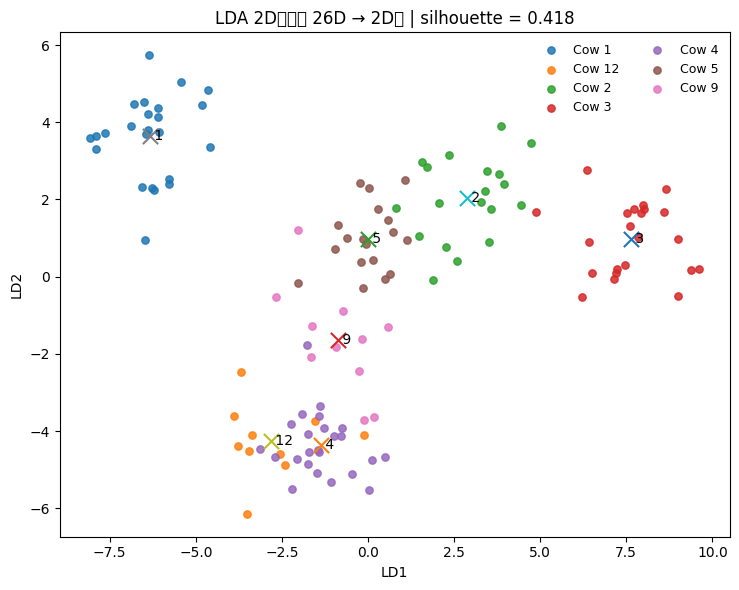

Saved: /home/ubuntu/yang/cow_frame/xml/landmark/figs/lda_scatter.png


In [12]:
# === Cell: LDA 2D 可視化（幾何 26D → LDA→2D）===
import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score

# 路徑（沿用你的專案結構）
PROJECT_ROOT = "/home/ubuntu/yang/cow_frame/xml/landmark"
MANIFEST_CSV = os.path.join(PROJECT_ROOT, "data", "manifest.csv")
OUT_DIR      = os.path.join(PROJECT_ROOT, "figs")
os.makedirs(OUT_DIR, exist_ok=True)
OUT_PNG      = os.path.join(OUT_DIR, "lda_scatter.png")

LABEL_ORDER = [
    "left_ear_up","left_ear_edge","left_ear_down",
    "right_ear_up","right_ear_edge","right_ear_down",
    "head","mouth_up","mouth_down",
    "left_nose","right_nose","left_eye","right_eye",
]
LIDX = {k:i for i,k in enumerate(LABEL_ORDER)}

def geom_26d_from_row(r):
    """取 13x2，做：去中心 → 除雙眼距 → 旋平 → 攤平成 26D。"""
    pts = np.array([[r[f"{lab}_x"], r[f"{lab}_y"]] for lab in LABEL_ORDER], dtype=np.float32)
    # 去中心
    cen = pts.mean(axis=0, keepdims=True)
    pts0 = pts - cen
    # 以雙眼距正規化
    le, re = pts0[LIDX["left_eye"]], pts0[LIDX["right_eye"]]
    io = np.linalg.norm(re - le)
    if io < 1e-6:
        return None  # 跳過異常
    pts1 = pts0 / io
    # 旋平（眼線水平）
    dy, dx = (re - le)[1], (re - le)[0]
    ang = math.atan2(dy, dx)
    ca, sa = math.cos(-ang), math.sin(-ang)
    R = np.array([[ca, -sa],[sa, ca]], dtype=np.float32)
    pts2 = (pts1 @ R.T)
    return pts2.reshape(-1)  # 26D

# 讀取資料，組訓練樣本
df = pd.read_csv(MANIFEST_CSV)
X_list, y_list = [], []
for _, r in df.iterrows():
    v = geom_26d_from_row(r)
    if v is None: 
        continue
    X_list.append(v)
    y_list.append(str(r["cow_id"]))
X = np.array(X_list, dtype=np.float32)
y = np.array(y_list)

# LDA 到 2D
le = LabelEncoder()
y_enc = le.fit_transform(y)
lda = LinearDiscriminantAnalysis(n_components=2)
Z = lda.fit_transform(X, y_enc)  # (N,2)

# silhouette（在 2D 空間）
sil = silhouette_score(Z, y_enc, metric="euclidean")

# 畫圖（不指定顏色，交給 matplotlib 預設調色盤）
plt.figure(figsize=(7.5,6))
for cid in np.unique(y):
    idx = (y == cid)
    plt.scatter(Z[idx,0], Z[idx,1], s=28, label=f"Cow {cid}", alpha=0.85)

# 畫每類中心
for cid in np.unique(y):
    idx = (y == cid)
    cx, cy = Z[idx,0].mean(), Z[idx,1].mean()
    plt.scatter([cx],[cy], s=120, marker="x")  # 類中心（預設色）
    plt.text(cx, cy, f" {cid}", fontsize=10, va="center")

plt.title(f"LDA 2D（幾何 26D → 2D） | silhouette = {sil:.3f}")
plt.xlabel("LD1"); plt.ylabel("LD2")
plt.legend(loc="best", ncol=2, fontsize=9, frameon=False)
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=180)
plt.show()

print("Saved:", OUT_PNG)


/tmp/ipykernel_4641/4048400810.py:190: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Sb += len(Xc) * float((diff.T @ diff))


[LDA 2D] 未轉正  Silhouette=0.559 | Fisher=134.643
[LDA 2D] 已轉正  Silhouette=0.734 | Fisher=99.886


/tmp/ipykernel_4641/4048400810.py:215: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4641/4048400810.py:215: UserWarning: Glyph 36681 (\N{CJK UNIFIED IDEOGRAPH-8F49}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4641/4048400810.py:215: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4641/4048400810.py:215: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4641/4048400810.py:215: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4641/4048400810.py:215: UserWarning: Glyph 24050 (\N{CJK UNIFIED IDEOGRAPH-5DF2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4641/4048400810.py:217: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRA

Saved plot to: /home/ubuntu/yang/cow_frame/xml/landmark/figs/lda_raw_vs_aligned.png


/home/ubuntu/YuChen/my_conda/envs/nerf/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/YuChen/my_conda/envs/nerf/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36681 (\N{CJK UNIFIED IDEOGRAPH-8F49}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/YuChen/my_conda/envs/nerf/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/YuChen/my_conda/envs/nerf/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ubuntu/YuChen/my_conda/envs/nerf/lib/python3.10/site-packa

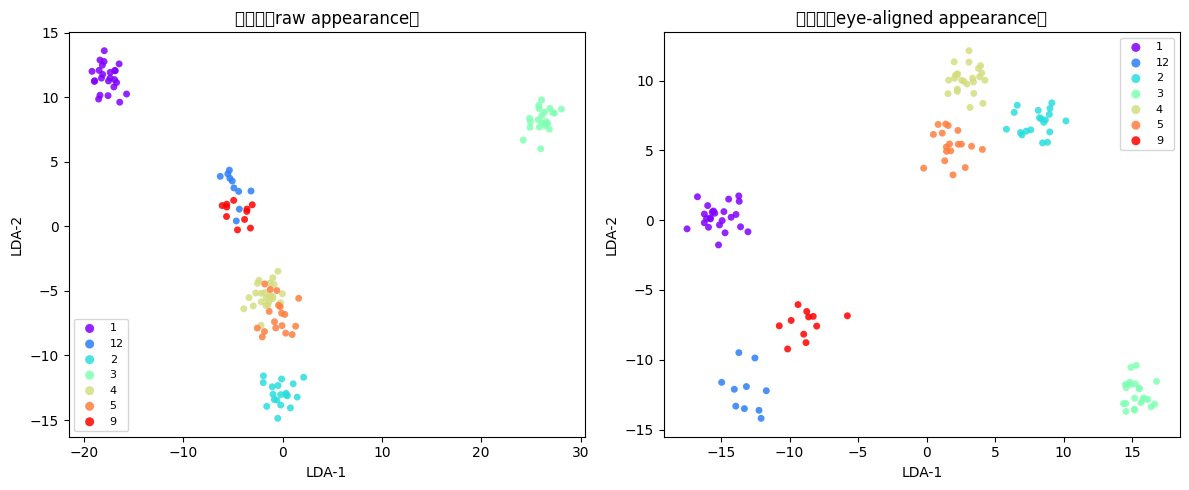

In [1]:
# === LDA 對照：未轉正 vs 已轉正（幾何26D + 外觀PCA32D） ===
import os, math, json, numpy as np, pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# scikit-learn
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# torch / torchvision
import torch
import torchvision
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn

# ---- 路徑設定（沿用你專案）----
PROJECT_ROOT = r"/home/ubuntu/yang/cow_frame/xml/landmark"
MANIFEST_CSV = os.path.join(PROJECT_ROOT, "data", "manifest.csv")
OUT_DIR = os.path.join(PROJECT_ROOT, "figs")
os.makedirs(OUT_DIR, exist_ok=True)

# ---- 標籤順序（與資料一致）----
LABEL_ORDER = [
    "left_ear_up","left_ear_edge","left_ear_down",
    "right_ear_up","right_ear_edge","right_ear_down",
    "head","mouth_up","mouth_down",
    "left_nose","right_nose","left_eye","right_eye",
]
LEI = LABEL_ORDER.index("left_eye")
REI = LABEL_ORDER.index("right_eye")

# ---- 參數 ----
OUT_SIZE = 256         # 對齊裁臉的輸出尺寸
TARGET_IO = 80.0       # 目標雙眼距（像素），可視需求調整
USE_GT = True          # True=用 GT 13點；False=改成用模型預測（需接 Predictor）

# ========= 幫手函數 =========
def load_points_from_row(row):
    pts = np.array([[row[f"{lab}_x"], row[f"{lab}_y"]] for lab in LABEL_ORDER], dtype=np.float32)
    return pts

def eye_roll_angle(le_xy, re_xy):
    dx, dy = re_xy[0]-le_xy[0], re_xy[1]-le_xy[1]
    return math.degrees(math.atan2(dy, dx))  # 左→右為0°；逆時針為正

def rotate_image_and_points(img: Image.Image, pts: np.ndarray, angle_deg: float):
    """對整張圖做旋轉（expand=True），並把 13 點一併旋到新圖座標。"""
    try:
        RES = Image.Resampling.BILINEAR
    except AttributeError:
        RES = Image.BILINEAR
    W,H = img.size
    img_rot = img.rotate(-angle_deg, resample=RES, expand=True)
    Wn,Hn = img_rot.size
    cx,cy = W/2.0, H/2.0
    rad = -angle_deg * math.pi/180.0
    ca, sa = math.cos(rad), math.sin(rad)
    x0,y0 = pts[:,0]-cx, pts[:,1]-cy
    xr = ca*x0 - sa*y0
    yr = sa*x0 + ca*y0
    nx, ny = xr + Wn/2.0, yr + Hn/2.0
    return img_rot, np.stack([nx,ny],1)

def crop_square_by_eyes(img: Image.Image, pts: np.ndarray, target_io=TARGET_IO, out_size=OUT_SIZE):
    """
    以雙眼中點為中心，根據 target_io 決定縮放，再裁成 out_size×out_size。
    （若沒轉正，就用原圖座標；若已轉正，就用轉正後座標）
    """
    W,H = img.size
    le, re = pts[LEI], pts[REI]
    io = float(np.linalg.norm(re - le)) or 1e-6
    s = target_io / io
    # 缩放後，希望眼間距是 target_io；用 out_size 作方框，確保整臉在内
    cx, cy = (le + re)/2.0
    # 反推在原圖上的方框邊長（縮放後 out_size -> 原圖座標對應 out_size/s）
    side = out_size / s
    x1 = int(round(cx - side/2)); y1 = int(round(cy - side/2))
    x2 = int(round(cx + side/2)); y2 = int(round(cy + side/2))
    # 邊界處理：pad 到能取到完整方框
    pad_l = max(0, -x1); pad_t = max(0, -y1)
    pad_r = max(0, x2 - W); pad_b = max(0, y2 - H)
    if pad_l or pad_t or pad_r or pad_b:
        canvas = Image.new("RGB", (W+pad_l+pad_r, H+pad_t+pad_b), (114,114,114))
        canvas.paste(img, (pad_l, pad_t))
        img = canvas
        x1 += pad_l; x2 += pad_l; y1 += pad_t; y2 += pad_t
    crop = img.crop((x1,y1,x2,y2)).resize((out_size,out_size), Image.BILINEAR)
    return crop

def geom_26D(pts: np.ndarray):
    """幾何 26D：去中心 / 除眼距 / 旋平（只做在座標，不動像素）"""
    v = pts.copy()
    centroid = v.mean(axis=0, keepdims=True)
    v -= centroid
    le, re = v[LEI], v[REI]
    io = float(np.linalg.norm(re - le)) or 1e-6
    v /= io
    dy, dx = (re - le)[1], (re - le)[0]
    ang = math.atan2(dy, dx)
    ca, sa = math.cos(-ang), math.sin(-ang)
    R = np.array([[ca,-sa],[sa,ca]], np.float32)
    v = (v @ R.T).reshape(-1)  # (26,)
    return v

# ========= 準備 ResNet18 外觀向量 =========
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
weights = ResNet18_Weights.IMAGENET1K_V1
enc = resnet18(weights=weights).to(device).eval()
enc.fc = nn.Identity()  # 取 512D
enc.eval()
# 官方 transforms（含 mean/std）
preprocess = weights.transforms()

def embed_appearance(pil_img: Image.Image):
    x = preprocess(pil_img).unsqueeze(0).to(device)
    with torch.no_grad(), torch.autocast(device_type='cuda', dtype=torch.float16, enabled=(device.type=='cuda')):
        f = enc(x).detach().cpu().numpy().reshape(-1)  # (512,)
    return f

# ========= 讀資料，建立兩組特徵 =========
df = pd.read_csv(MANIFEST_CSV)
Xs_geom, Xs_app_raw, Xs_app_align, ys = [], [], [], []

for _, r in df.iterrows():
    img = Image.open(r["image_path"]).convert("RGB")
    pts = load_points_from_row(r) if USE_GT else None  # 需要可改成模型預測

    # 幾何 26D（相同，讓我們隔離出「外觀是否轉正」的影響）
    g26 = geom_26D(pts)

    # A) 未轉正外觀（只依雙眼距作尺度的不旋轉裁切）
    crop_raw = crop_square_by_eyes(img, pts, target_io=TARGET_IO, out_size=OUT_SIZE)
    a512_raw = embed_appearance(crop_raw)

    # B) 已轉正外觀（先把眼線旋到水平，再用相同規則裁切）
    angle = eye_roll_angle(pts[LEI], pts[REI])
    img_rot, pts_rot = rotate_image_and_points(img, pts, angle)
    crop_aln = crop_square_by_eyes(img_rot, pts_rot, target_io=TARGET_IO, out_size=OUT_SIZE)
    a512_aln = embed_appearance(crop_aln)

    Xs_geom.append(g26)
    Xs_app_raw.append(a512_raw)
    Xs_app_align.append(a512_aln)
    ys.append(str(r["cow_id"]))

Xs_geom = np.array(Xs_geom, dtype=np.float32)            # (N,26)
Xs_app_raw = np.array(Xs_app_raw, dtype=np.float32)      # (N,512)
Xs_app_align = np.array(Xs_app_align, dtype=np.float32)  # (N,512)
ys = np.array(ys)

# ========= PCA 將外觀 512D 壓到 32D（同一個 PCA，避免偏差）=========
pca = PCA(n_components=min(32, min(len(df), 512)-1), random_state=42)
X_app_all = np.concatenate([Xs_app_raw, Xs_app_align], axis=0)
pca.fit(X_app_all)
A32_raw   = pca.transform(Xs_app_raw)
A32_align = pca.transform(Xs_app_align)

# ========= 融合（幾何 26D + 外觀 32D），各自 z-score 後 concat =========
sc_g = StandardScaler().fit(Xs_geom)
sc_a = StandardScaler().fit(np.vstack([A32_raw, A32_align]))  # 用同一個標準化器

Gz   = sc_g.transform(Xs_geom)
Az_r = sc_a.transform(A32_raw)
Az_a = sc_a.transform(A32_align)

X_raw   = np.concatenate([Gz, Az_r], axis=1)
X_align = np.concatenate([Gz, Az_a], axis=1)

# ========= LDA → 2D =========
lda_raw   = LDA(n_components=2).fit(X_raw, ys)
lda_align = LDA(n_components=2).fit(X_align, ys)
Z_raw   = lda_raw.transform(X_raw)
Z_align = lda_align.transform(X_align)

# ========= 分群指標（越大越好）=========
def fisher_ratio(X, y):
    # 簡單版 Fisher: trace(S_B) / trace(S_W)
    X = np.asarray(X, np.float32); y = np.asarray(y)
    mu = X.mean(axis=0)
    # 類內
    Sw = 0.0
    # 類間
    Sb = 0.0
    for c in np.unique(y):
        Xc = X[y==c]; mc = Xc.mean(axis=0)
        Sw += np.trace(np.cov(Xc.T)) * (len(Xc)-1)
        diff = (mc - mu).reshape(-1,1)
        Sb += len(Xc) * float((diff.T @ diff))
    return Sb / max(Sw, 1e-6)

sil_raw   = silhouette_score(Z_raw, ys, metric='euclidean')
sil_align = silhouette_score(Z_align, ys, metric='euclidean')
fr_raw    = fisher_ratio(Z_raw, ys)
fr_align  = fisher_ratio(Z_align, ys)

print(f"[LDA 2D] 未轉正  Silhouette={sil_raw:.3f} | Fisher={fr_raw:.3f}")
print(f"[LDA 2D] 已轉正  Silhouette={sil_align:.3f} | Fisher={fr_align:.3f}")

# ========= 視覺化 =========
import matplotlib.cm as cm
plt.figure(figsize=(12,5))
for j,(Z,title) in enumerate([(Z_raw,"未轉正（raw appearance）"),
                              (Z_align,"已轉正（eye-aligned appearance）")], start=1):
    plt.subplot(1,2,j)
    # 一個類別一個顏色
    classes = sorted(np.unique(ys))
    colors = cm.rainbow(np.linspace(0,1,len(classes)))
    for c,col in zip(classes, colors):
        mask = (ys==c)
        plt.scatter(Z[mask,0], Z[mask,1], s=25, color=col, label=str(c), alpha=0.85, edgecolors='none')
    plt.title(title)
    plt.xlabel("LDA-1"); plt.ylabel("LDA-2"); plt.legend(markerscale=1.3, fontsize=8)
plt.tight_layout()
png_path = os.path.join(OUT_DIR, "lda_raw_vs_aligned.png")
plt.savefig(png_path, dpi=180)
print("Saved plot to:", png_path)


In [15]:
# === Cell: Identity F1 (closed-set / open-set) using Predictor + prototypes ===
import os, json, numpy as np, pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from predictor import Predictor

# 路徑
PROJECT_ROOT = "/home/ubuntu/yang/cow_frame/xml/landmark"
BUNDLE       = os.path.join(PROJECT_ROOT, "release")
VAL_CSV      = os.path.join(PROJECT_ROOT, "data", "manifest_val.csv")
ALL_CSV      = os.path.join(PROJECT_ROOT, "data", "manifest.csv")
MANIFEST_CSV = VAL_CSV if os.path.exists(VAL_CSV) else ALL_CSV

# 載入模型/工具
pred = Predictor(BUNDLE)  # 會自動挑 GPU/CPU

LABEL_ORDER   = pred.LABEL_ORDER
LEFT_EYE_IDX  = LABEL_ORDER.index("left_eye")
RIGHT_EYE_IDX = LABEL_ORDER.index("right_eye")

def vec26_from_pts256(pts256: np.ndarray) -> np.ndarray:
    """把 13x2 轉成『中心化→以眼距正規化→旋平眼線』後的 26 維向量（與 prototypes 同規則）"""
    v = pts256.astype(np.float32).copy()
    v = v - v.mean(axis=0, keepdims=True)
    le, re = v[LEFT_EYE_IDX], v[RIGHT_EYE_IDX]
    io = np.linalg.norm(re - le) or 1e-6
    v = v / io
    dy, dx = (re - le)[1], (re - le)[0]
    ang = np.arctan2(dy, dx)
    ca, sa = np.cos(-ang), np.sin(-ang)
    R = np.array([[ca, -sa], [sa, ca]], dtype=np.float32)
    return (v @ R.T).reshape(-1)  # (26,)

def cosine_sim(a, b):  # a: (n, d), b: (m, d) -> (n, m)
    a = a / (np.linalg.norm(a, axis=1, keepdims=True) + 1e-9)
    b = b / (np.linalg.norm(b, axis=1, keepdims=True) + 1e-9)
    return a @ b.T

# 讀 prototypes（優先 BUNDLE，否則 infer 資料夾）
proto_path = os.path.join(BUNDLE, "prototypes.json")
if not os.path.exists(proto_path):
    alt = os.path.join(PROJECT_ROOT, "infer", "prototypes.json")
    if os.path.exists(alt): proto_path = alt
protos = None
if os.path.exists(proto_path):
    with open(proto_path, "r") as f:
        dat = json.load(f)
        # 兼容兩種格式：{"prototypes": {"1":[...], ...}} 或 {"1":[...], ...}
        if "prototypes" in dat: dat = dat["prototypes"]
        protos = {str(k): np.array(v, dtype=np.float32) for k, v in dat.items()}

# 讀 open-set threshold（若有就做 open-set 版本）
T = None
T_path = os.path.join(BUNDLE, "threshold.json")
if not os.path.exists(T_path):
    alt = os.path.join(PROJECT_ROOT, "infer", "threshold.json")
    if os.path.exists(alt): T_path = alt
if os.path.exists(T_path):
    with open(T_path, "r") as f:
        T = float(json.load(f).get("T", None))

# 若沒有 prototypes，就用「訓練好的 prototypes 缺失」的備案：用 manifest 內每頭牛的平均『GT 幾何向量』建立
#（注意：這會稍微樂觀；建議優先用訓練時產生的 prototypes.json）
if protos is None:
    print("[Warn] prototypes.json 未找到，臨時用 GT 幾何向量平均建立（較樂觀）。")
    df_all = pd.read_csv(ALL_CSV)
    tmp = {}
    for cid, g in df_all.groupby("cow_id"):
        # 用 GT 原圖座標 → 映到 256 需要 letterbox meta；Predictor 內部沒有直接轉換 GT，
        # 為簡便這裡用「模型預測的 kpt_256」近似建立（會更樂觀）
        vs = []
        for _, r in g.iterrows():
            out = pred.predict_keypoints(r["image_path"])
            vs.append(vec26_from_pts256(out["kpt_256"]))
        protos[str(cid)] = np.mean(np.stack(vs, 0), axis=0)

# 準備 prototype 矩陣
cow_ids = sorted(protos.keys(), key=lambda x: int(x) if str(x).isdigit() else x)
P = np.stack([protos[k] for k in cow_ids], 0)  # (C, 26)

# 跑整批並計算 F1
df = pd.read_csv(MANIFEST_CSV)
y_true, y_pred_closed, y_pred_open = [], [], []
rows = []

for _, r in df.iterrows():
    cid = str(r["cow_id"])
    out = pred.predict_keypoints(r["image_path"])
    v26 = vec26_from_pts256(out["kpt_256"]).reshape(1, -1)

    sims = cosine_sim(v26, P).flatten()
    best = int(np.argmax(sims))
    pred_c = cow_ids[best]
    y_true.append(cid)
    y_pred_closed.append(pred_c)

    # open-set（若有 T）
    if T is not None and float(sims[best]) < T:
        y_pred_open.append("unknown")
    else:
        y_pred_open.append(pred_c)

    rows.append({
        "image_path": r["image_path"],
        "gt": cid, "pred": pred_c,
        "max_sim": float(sims[best]),
        "is_unknown": (T is not None and float(sims[best]) < T)
    })

pred_csv = os.path.join(PROJECT_ROOT, "train", "logs", "id_eval_predictions.csv")
pd.DataFrame(rows).to_csv(pred_csv, index=False)
print("Saved identity predictions to:", pred_csv)

# 1) Closed-set（不考慮 unknown）
print("\n=== Closed-set (no unknown) ===")
print(classification_report(y_true, y_pred_closed, digits=4, labels=cow_ids))
print("F1 macro:", f1_score(y_true, y_pred_closed, average="macro", labels=cow_ids))
print("F1 micro:", f1_score(y_true, y_pred_closed, average="micro", labels=cow_ids))
print("Confusion:\n", confusion_matrix(y_true, y_pred_closed, labels=cow_ids))

# 2) Open-set（把低相似度者標成 'unknown'）
if T is not None:
    labels_open = cow_ids + ["unknown"]
    print("\n=== Open-set (with 'unknown') ===")
    print(classification_report(y_true, y_pred_open, digits=4, labels=labels_open))
    print("F1 macro (open-set):", f1_score(y_true, y_pred_open, average="macro", labels=labels_open))
    print("F1 micro (open-set):", f1_score(y_true, y_pred_open, average="micro", labels=labels_open))
    print("Confusion (open-set):\n", confusion_matrix(y_true, y_pred_open, labels=labels_open))
else:
    print("\n(No threshold.json found; skipped open-set F1.)")


Saved identity predictions to: /home/ubuntu/yang/cow_frame/xml/landmark/train/logs/id_eval_predictions.csv

=== Closed-set (no unknown) ===
              precision    recall  f1-score   support

           1     0.1333    0.4000    0.2000         5
           2     0.0000    0.0000    0.0000         4
           3     0.0000    0.0000    0.0000         4
           4     0.0000    0.0000    0.0000         5
           5     0.0000    0.0000    0.0000         4
           9     0.2222    1.0000    0.3636         2
          12     0.0000    0.0000    0.0000         2

    accuracy                         0.1538        26
   macro avg     0.0508    0.2000    0.0805        26
weighted avg     0.0427    0.1538    0.0664        26

F1 macro: 0.08051948051948053
F1 micro: 0.15384615384615385
Confusion:
 [[2 0 0 0 0 3 0]
 [3 0 0 0 0 1 0]
 [1 0 0 0 0 3 0]
 [3 0 2 0 0 0 0]
 [4 0 0 0 0 0 0]
 [0 0 0 0 0 2 0]
 [2 0 0 0 0 0 0]]

=== Open-set (with 'unknown') ===
              precision    recall  f

/home/ubuntu/YuChen/my_conda/envs/nerf/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ubuntu/YuChen/my_conda/envs/nerf/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ubuntu/YuChen/my_conda/envs/nerf/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

In [2]:
# Cell R2 — Head pose (solvePnP) from your 13 points → face normal

import cv2, numpy as np

# 你 13 點在原圖的 (x,y)，以及左右眼索引
# pts_orig: (13,2) float32
# left_eye_idx, right_eye_idx 依你的 LABEL_ORDER

def build_cow3d_template(pts_orig, left_eye_idx, right_eye_idx):
    """回傳對應到你 2D 點的 3D 基準點（單位：眼距=1；原點=眼中點；Z 朝向相機）"""
    le = pts_orig[left_eye_idx]; re = pts_orig[right_eye_idx]
    iod = np.linalg.norm(re - le) + 1e-6

    # 定義 3D：眼在 (-0.5,0,0) 與 (0.5,0,0)
    # 鼻子、嘴、額頭用簡化牛頭比例（可日後微調）
    # 順序要對應你的 LABEL_ORDER
    # 例：["left_ear_up","left_ear_edge","left_ear_down",
    #      "right_ear_up","right_ear_edge","right_ear_down",
    #      "head","mouth_up","mouth_down","left_nose","right_nose",
    #      "left_eye","right_eye"]
    # 我們主要信任：left/right_eye、head(額頭/眉間近處)、nose(兩鼻孔中點附近)、mouth_up/down
    # 耳朵較軟，可給較小權重或先不放入 PnP。
    template = {
        "left_eye":  (-0.5,  0.00, 0.00),
        "right_eye": ( 0.5,  0.00, 0.00),
        "head":      ( 0.0,  0.35, 0.15),  # 額頭略上且略向外
        "mouth_up":  ( 0.0, -0.55, 0.55),
        "mouth_down":( 0.0, -0.75, 0.50),
        "nose_ctr":  ( 0.0, -0.35, 0.70),  # 兩鼻孔中點
    }
    # 轉成 numpy
    name_order = ["left_eye","right_eye","head","mouth_up","mouth_down","nose_ctr"]
    P3D = np.array([template[n] for n in name_order], dtype=np.float32)  # (M,3)
    return P3D, name_order

def collect_2d_correspondences(pts_orig, labels, name_order):
    """把 2D 取出並構造 'nose_ctr'（鼻孔中點）。labels=你的 LABEL_ORDER"""
    lab2idx = {lab:i for i, lab in enumerate(labels)}
    # 構造鼻孔中點
    ln = pts_orig[lab2idx["left_nose"]]
    rn = pts_orig[lab2idx["right_nose"]]
    nose_ctr = (ln + rn)/2.0

    pick = {
        "left_eye":  pts_orig[lab2idx["left_eye"]],
        "right_eye": pts_orig[lab2idx["right_eye"]],
        "head":      pts_orig[lab2idx["head"]],
        "mouth_up":  pts_orig[lab2idx["mouth_up"]],
        "mouth_down":pts_orig[lab2idx["mouth_down"]],
        "nose_ctr":  nose_ctr,
    }
    P2D = np.array([pick[n] for n in name_order], dtype=np.float32)
    return P2D

def estimate_head_pose_from_13(
    img_shape, pts_orig, labels, left_eye_idx, right_eye_idx
):
    """
    回傳：rvec(3,), tvec(3,), R(3x3), face_normal_cam(3,), reproj_err
    """
    H, W = img_shape[:2]
    # 內參（近似）：f ~ max(W,H)，光心在中心，零畸變
    f = float(max(W, H))
    K = np.array([[f, 0, W/2.0],
                  [0, f, H/2.0],
                  [0, 0, 1.0]], dtype=np.float32)
    dist = np.zeros((4,1), dtype=np.float32)

    P3D, name_order = build_cow3d_template(pts_orig, left_eye_idx, right_eye_idx)
    P2D = collect_2d_correspondences(pts_orig, labels, name_order)

    ok, rvec, tvec = cv2.solvePnP(
        P3D, P2D, K, dist, flags=cv2.SOLVEPNP_ITERATIVE
    )
    if not ok:
        raise RuntimeError("solvePnP failed")

    R, _ = cv2.Rodrigues(rvec)
    # 相機座標系的「臉部法向量」：世界 Z 軸(0,0,1) 經 R 轉到相機坐標
    face_normal_cam = (R @ np.array([0,0,1.0], dtype=np.float32)).reshape(-1)

    # re-projection error（方便你檢查幾何是否合理）
    proj, _ = cv2.projectPoints(P3D, rvec, tvec, K, dist)  # (M,1,2)
    proj = proj[:,0,:]
    reproj_err = float(np.mean(np.linalg.norm(proj - P2D, axis=1)))

    return rvec, tvec, R, face_normal_cam, reproj_err


In [5]:
from PIL import Image

def estimate_head_pose_from_image(img_or_shape, pts_orig, labels, left_eye_idx, right_eye_idx):
    # img_or_shape 可以是 PIL.Image、NumPy image、或 (H,W[,C]) 的 shape tuple
    if isinstance(img_or_shape, tuple):
        H, W = img_or_shape[:2]
    elif isinstance(img_or_shape, Image.Image):
        W, H = img_or_shape.size
    else:  # NumPy image
        H, W = img_or_shape.shape[:2]
    return estimate_head_pose_from_13((H, W, 3), pts_orig.astype(np.float32), labels, left_eye_idx, right_eye_idx)

# 用法
res  = pred.predict_keypoints("/home/ubuntu/yang/cow_frame/xml/images/431711.png")
img  = res["img"]             # PIL.Image
pts  = res["kpt_orig"]
labels = pred.LABEL_ORDER
le = labels.index("left_eye"); re = labels.index("right_eye")

rvec, tvec, R, n_cam, reproj = estimate_head_pose_from_image(img, pts, labels, le, re)
print("face normal:", n_cam, "| reproj err(px):", reproj)


face normal: [-0.87586573 -0.47016844  0.10863174] | reproj err(px): 580.1773071289062


In [1]:
# === Cell B1: 用 13 點標註自動產生 YOLO 偵測資料集（train/val split + data.yaml） ===
import os, shutil, math
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 路徑沿用你先前專案
PROJECT_ROOT = r"/home/ubuntu/yang/cow_frame/xml/landmark"
IMAGES_ROOT  = r"/home/ubuntu/yang/cow_frame/xml/images"
MANIFEST_CSV = os.path.join(PROJECT_ROOT, "data", "manifest.csv")

DATASET_ROOT = os.path.join(PROJECT_ROOT, "yolo", "dataset")
IMG_TR = os.path.join(DATASET_ROOT, "images", "train")
IMG_VA = os.path.join(DATASET_ROOT, "images", "val")
LAB_TR = os.path.join(DATASET_ROOT, "labels", "train")
LAB_VA = os.path.join(DATASET_ROOT, "labels", "val")
for d in [IMG_TR, IMG_VA, LAB_TR, LAB_VA]:
    os.makedirs(d, exist_ok=True)

# 讀 manifest
df = pd.read_csv(MANIFEST_CSV)

LABEL_ORDER = [
    "left_ear_up","left_ear_edge","left_ear_down",
    "right_ear_up","right_ear_edge","right_ear_down",
    "head","mouth_up","mouth_down",
    "left_nose","right_nose","left_eye","right_eye",
]

def row_to_bbox(row, margin=0.15):
    """由 13 點外接框 + 邊界外擴，回傳 xywh（YOLO 需求是中心點+寬高的正規化）"""
    W, H = float(row["width"]), float(row["height"])
    xs, ys = [], []
    for lab in LABEL_ORDER:
        xs.append(float(row[f"{lab}_x"]))
        ys.append(float(row[f"{lab}_y"]))
    xmin, xmax = max(0.0, min(xs)), min(W-1.0, max(xs))
    ymin, ymax = max(0.0, min(ys)), min(H-1.0, max(ys))
    bw, bh = xmax - xmin, ymax - ymin
    # 邊界外擴
    cx, cy = xmin + bw/2.0, ymin + bh/2.0
    bw *= (1.0 + margin*2.0)
    bh *= (1.0 + margin*2.0)
    # 重新夾回邊界
    bw = min(bw, W-1.0)
    bh = min(bh, H-1.0)
    cx = min(max(cx, bw/2.0), W - bw/2.0)
    cy = min(max(cy, bh/2.0), H - bh/2.0)
    return cx, cy, bw, bh, W, H

def save_yolo_label(txt_path, cx, cy, bw, bh, W, H, cls_id=0):
    x = cx / W; y = cy / H; w = bw / W; h = bh / H
    with open(txt_path, "w") as f:
        f.write(f"{cls_id} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")

# 依 cow_id 分層 80/20
idx = np.arange(len(df))
tr_idx, va_idx = train_test_split(
    idx, test_size=0.2, random_state=42, stratify=df["cow_id"]
)
split_map = {"train": set(tr_idx), "val": set(va_idx)}

# 輸出影像與標籤
def place(sample_idx, split):
    row = df.iloc[sample_idx]
    src_img = row["image_path"]
    base = os.path.basename(src_img)
    dst_img = os.path.join(IMG_TR if split=="train" else IMG_VA, base)
    dst_lab = os.path.join(LAB_TR if split=="train" else LAB_VA, os.path.splitext(base)[0] + ".txt")
    # 複製影像
    shutil.copy2(src_img, dst_img)
    # 產生 YOLO label
    cx, cy, bw, bh, W, H = row_to_bbox(row, margin=0.15)
    save_yolo_label(dst_lab, cx, cy, bw, bh, W, H, cls_id=0)

for i in tr_idx: place(i, "train")
for i in va_idx: place(i, "val")

# 建 data.yaml
DATA_YAML = os.path.join(PROJECT_ROOT, "yolo", "data.yaml")
with open(DATA_YAML, "w") as f:
    f.write(
f"""# auto-generated
path: {DATASET_ROOT}
train: images/train
val: images/val
names:
  0: cow_face
"""
    )

print("YOLO dataset ready.")
print("train images:", len(tr_idx), "| val images:", len(va_idx))
print("data.yaml:", DATA_YAML)


YOLO dataset ready.
train images: 102 | val images: 26
data.yaml: /home/ubuntu/yang/cow_frame/xml/landmark/yolo/data.yaml


In [2]:
# === Cell B2: 訓練 YOLO 偵測器（Ultralytics YOLOv8n） ===
import os, sys, subprocess

PROJECT_ROOT = r"/home/ubuntu/yang/cow_frame/xml/landmark"
DATA_YAML    = os.path.join(PROJECT_ROOT, "yolo", "data.yaml")
RUNS_DIR     = os.path.join(PROJECT_ROOT, "yolo", "runs")
os.makedirs(RUNS_DIR, exist_ok=True)

# 安裝 ultralytics（若尚未安裝）
try:
    from ultralytics import YOLO
except Exception:
    print("Installing ultralytics ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "ultralytics"])
    from ultralytics import YOLO

import torch
device = 0 if torch.cuda.is_available() else "cpu"

# 輕量模型（也可改 'yolov8s.pt' 等）
model = YOLO("yolov8n.pt")

results = model.train(
    data=DATA_YAML,
    imgsz=640,
    epochs=80,
    batch=16,
    device=device,
    project=RUNS_DIR,
    name="cow_face_det",
    exist_ok=True,
    patience=20
)

# 取得 best 權重路徑（供下一個 Cell 使用）
try:
    YOLO_WEIGHTS = results.best
except Exception:
    # 若無 results.best，按預設路徑推測
    YOLO_WEIGHTS = os.path.join(RUNS_DIR, "cow_face_det", "weights", "best.pt")

print("YOLO best weights:", YOLO_WEIGHTS)


Installing ultralytics ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 9.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.7/39.7 MB 19.9 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ultralytics] [ultralytics]thop]
Ultralytics 8.3.199 🚀 Python-3.10.18 torch-2.5.1+cu121 CUDA:0 (NVIDIA RTX A6000, 48670MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/ubuntu/yang/cow_frame/xml/landmark/yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj

COMET ERROR: Failed to create Comet experiment, reason: ValueError('Comet.ml requires an API key. Please provide as the first argument to Experiment(api_key) or as an environment variable named COMET_API_KEY ')


WARNING ⚠️ Comet installed but not initialized correctly, not logging this run. Comet.ml requires an API key. Please provide as the first argument to Experiment(api_key) or as an environment variable named COMET_API_KEY 
Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.mod